In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv


#### Code

2026-04-07 21:50:23.319587: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775598623.546249      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775598623.608272      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775598624.111013      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775598624.111053      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775598624.111057      55 computation_placer.cc:177] computation placer alr

Train shape: (3046, 3800, 1)
Test shape : (762, 3800, 1)
Classes    : 3

Training Hybrid_Full


I0000 00:00:1775598651.382276      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "CTHM_with_PosEnc"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 3800, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 3800, 1)   │          0 │ input_layer[0][0] │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 3800, 8)   │        520 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 3800, 8)   │         32 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 3800, 16)  │      2,064 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3800, 16)  │         64 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 3800, 16)  │        272 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3800, 16)  │         64 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling1d   │ (None, 475, 16)   │          0 │ batch_normalizat… │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 475, 16)   │          0 │ average_pooling1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 475, 16)   │          0 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 475, 16)   │      4,304 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 475, 16)   │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 475, 16)   │         32 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 475, 64)   │      1,088 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 475, 64)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 475, 16)   │      1,040 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 475, 16)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 475, 16)   │         32 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

...

Epoch 1/500


I0000 00:00:1775598658.744909     122 service.cc:152] XLA service 0x7c1884003190 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775598658.744963     122 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775598660.122945     122 cuda_dnn.cc:529] Loaded cuDNN version 91002


15/77 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3093 - loss: 25.0754

I0000 00:00:1775598667.036102     122 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


77/77 ━━━━━━━━━━━━━━━━━━━━ 24s 139ms/step - accuracy: 0.3837 - loss: 24.7330 - val_accuracy: 0.6148 - val_loss: 23.6335 - learning_rate: 5.0000e-05
Epoch 2/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5246 - loss: 23.5210 - val_accuracy: 0.6426 - val_loss: 22.6901 - learning_rate: 5.0000e-05
Epoch 3/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5844 - loss: 22.5054 - val_accuracy: 0.6672 - val_loss: 21.7702 - learning_rate: 5.0000e-05
Epoch 4/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6036 - loss: 21.6300 - val_accuracy: 0.6787 - val_loss: 20.8836 - learning_rate: 5.0000e-05
Epoch 5/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6512 - loss: 20.6899 - val_accuracy: 0.7082 - val_loss: 20.0046 - learning_rate: 5.0000e-05
Epoch 6/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6543 - loss: 19.8311 - val_accuracy: 0.7344 - val_loss: 19.1519 - learning_rate: 5.0000e-05
Epoch 7/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy

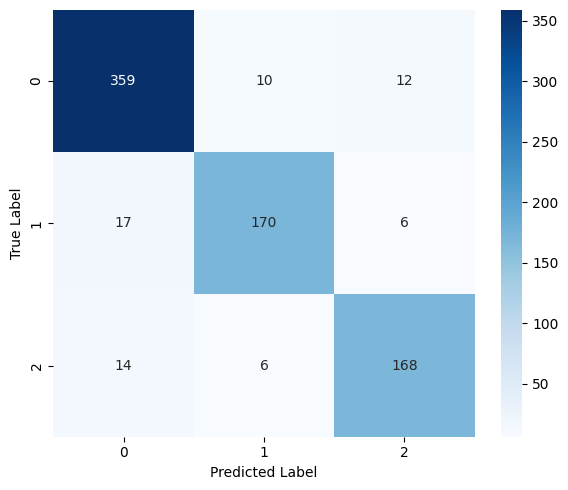

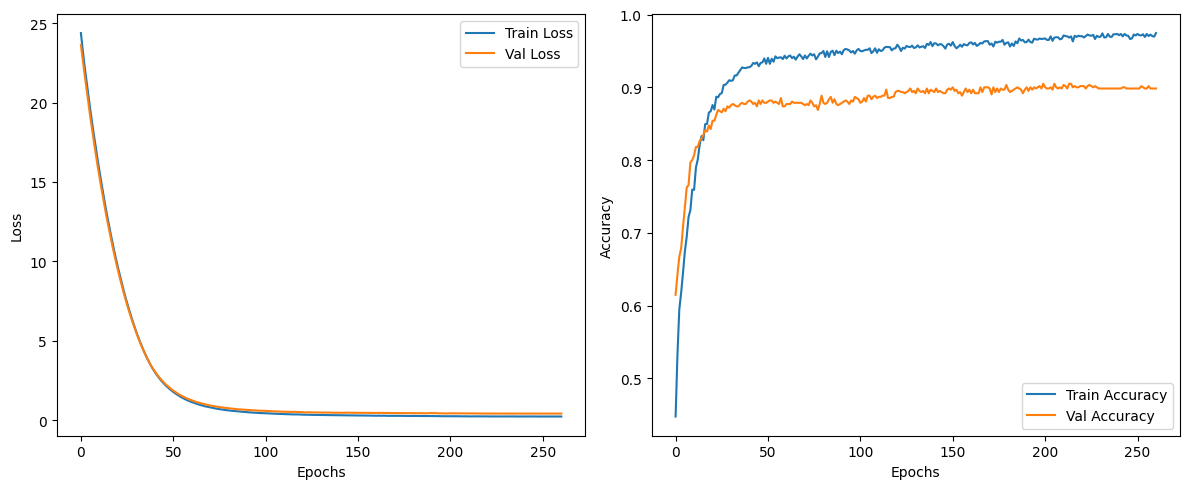

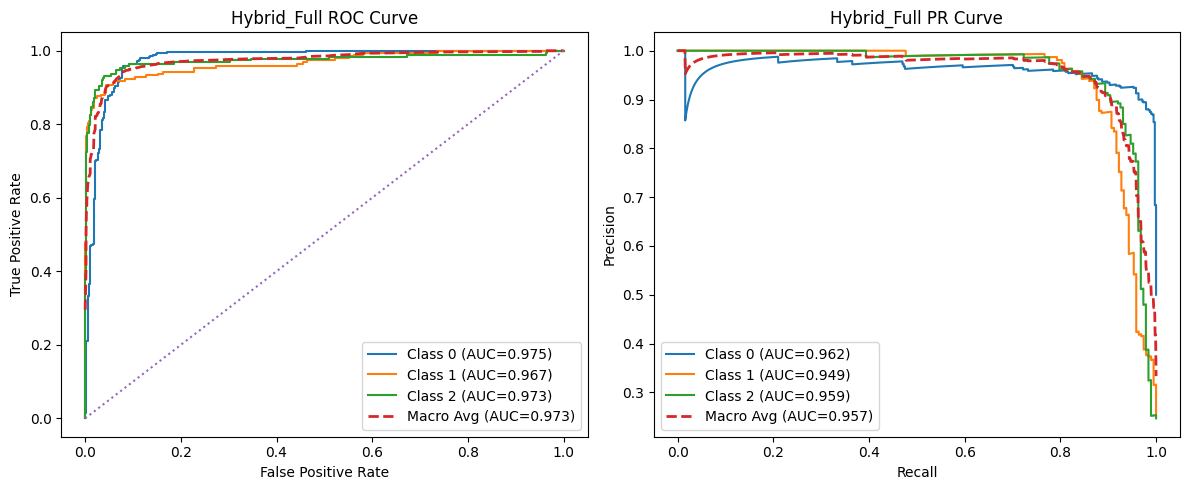


Training CNN_Only


Model: "CNN_Only"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 3800, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_1                │ (None, 3800, 1)        │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 3800, 8)        │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 3800, 8)        │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 3800, 16)       │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 3800, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 3800, 16)       │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 3800, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_1             │ (None, 475, 16)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 475, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 7600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       486,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 489,675 (1.87 MB)

 Trainable params: 489,595 (1.87 MB)

 Non-trainable params: 80 (320.00 B)

Epoch 1/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step - accuracy: 0.3181 - loss: 45.4871 - val_accuracy: 0.5639 - val_loss: 38.9715 - learning_rate: 5.0000e-05
Epoch 2/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4736 - loss: 37.3808 - val_accuracy: 0.6443 - val_loss: 31.8572 - learning_rate: 5.0000e-05
Epoch 3/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5038 - loss: 30.4964 - val_accuracy: 0.6754 - val_loss: 25.7273 - learning_rate: 5.0000e-05
Epoch 4/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5712 - loss: 24.5406 - val_accuracy: 0.7000 - val_loss: 20.5918 - learning_rate: 5.0000e-05
Epoch 5/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6364 - loss: 19.5910 - val_accuracy: 0.7279 - val_loss: 16.5561 - learning_rate: 5.0000e-05
Epoch 6/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6496 - loss: 15.7897 - val_accuracy: 0.7410 - val_loss: 13.4649 - learning_rate: 5.0000e-05
Epoch 7/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc

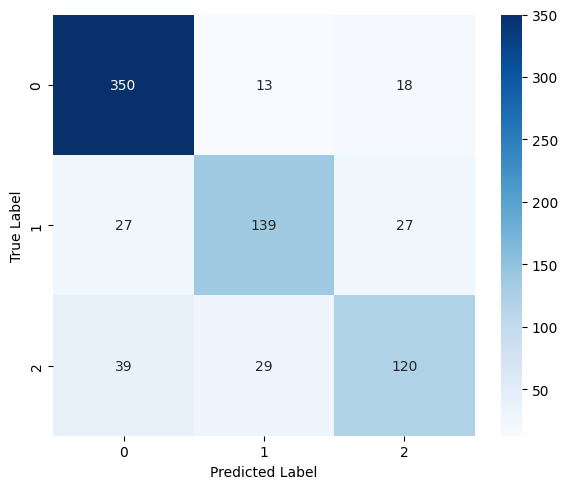

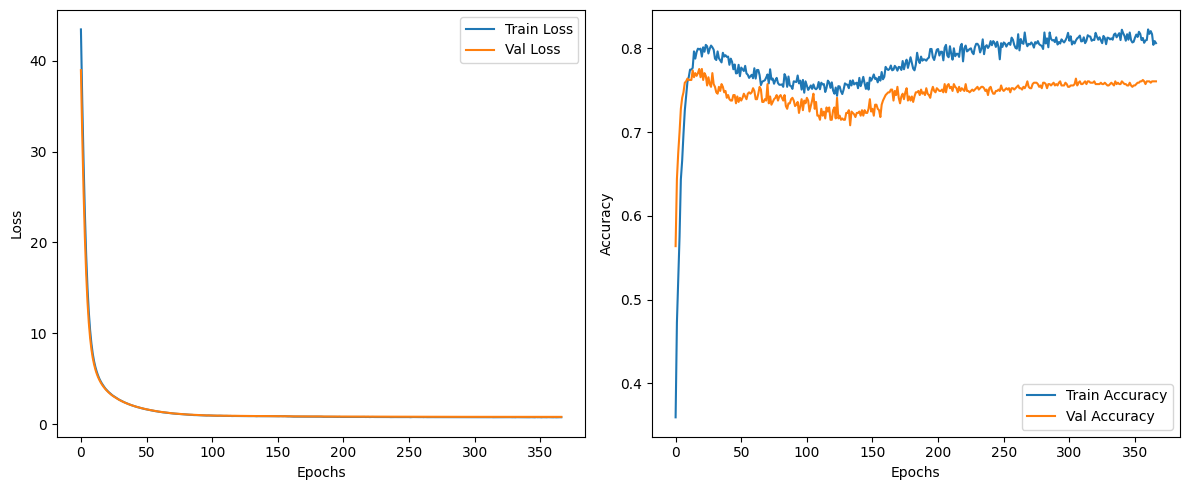

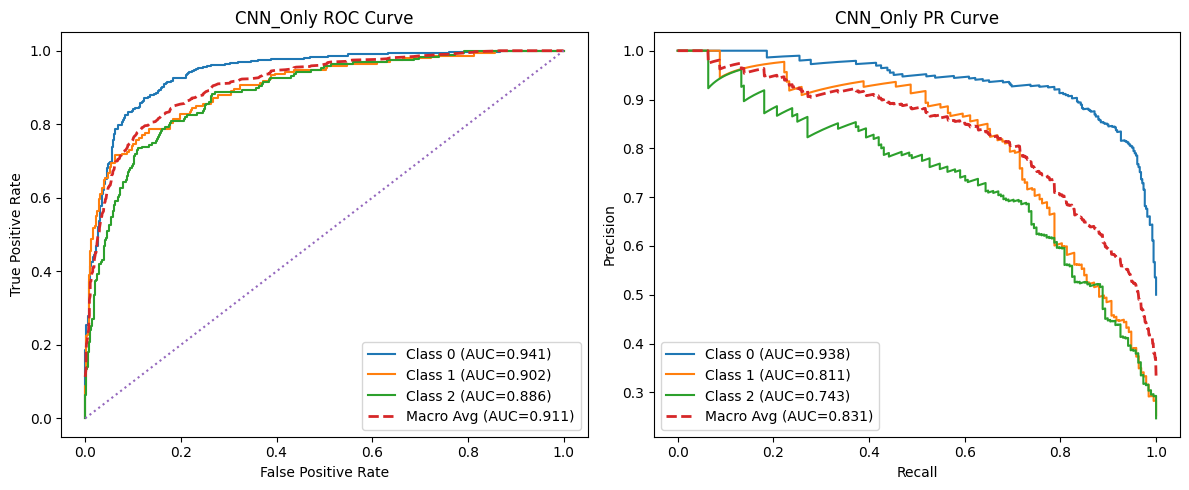


Training Transformer_Only


Model: "Transformer_Only"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 3800, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_2    │ (None, 3800, 1)   │          0 │ input_layer_2[0]… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 3800, 16)  │         32 │ gaussian_noise_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3800, 16)  │         64 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling1d_2 │ (None, 475, 16)   │          0 │ batch_normalizat… │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 475, 16)   │          0 │ average_pooling1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 475, 16)   │          0 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 475, 16)   │      4,304 │ add_3[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 475, 16)   │          0 │ add_3[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 475, 16)   │         32 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 475, 64)   │      1,088 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 475, 64)   │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 475, 16)   │      1,040 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 475, 16)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 475, 16)   │         32 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 7600)      │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 3)         │     22,803 │ flatten_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 29,395 (114.82 KB)

 Trainable params: 29,363 (114.70 KB)

 Non-trainable params: 32 (128.00 B)

Epoch 1/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 17s 105ms/step - accuracy: 0.3559 - loss: 17.8310 - val_accuracy: 0.5311 - val_loss: 17.0891 - learning_rate: 5.0000e-05
Epoch 2/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5033 - loss: 16.8853 - val_accuracy: 0.5803 - val_loss: 16.2757 - learning_rate: 5.0000e-05
Epoch 3/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5667 - loss: 16.0619 - val_accuracy: 0.6016 - val_loss: 15.5694 - learning_rate: 5.0000e-05
Epoch 4/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5668 - loss: 15.4211 - val_accuracy: 0.6180 - val_loss: 14.9100 - learning_rate: 5.0000e-05
Epoch 5/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6027 - loss: 14.7400 - val_accuracy: 0.6361 - val_loss: 14.2796 - learning_rate: 5.0000e-05
Epoch 6/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6072 - loss: 14.1478 - val_accuracy: 0.6475 - val_loss: 13.6792 - learning_rate: 5.0000e-05
Epoch 7/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/ste

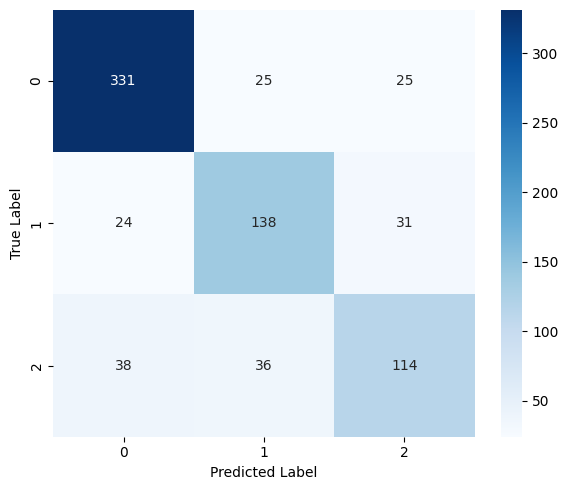

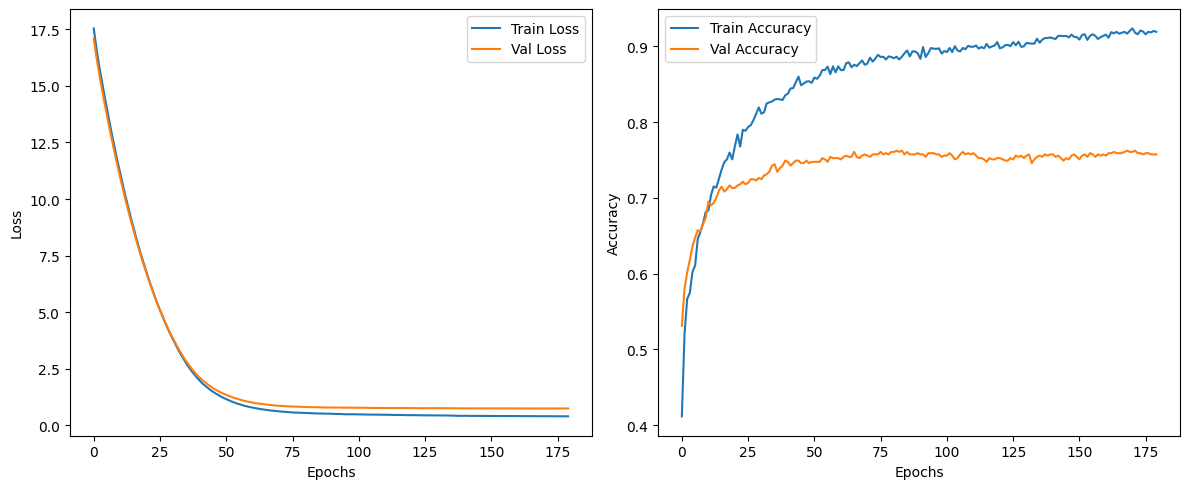

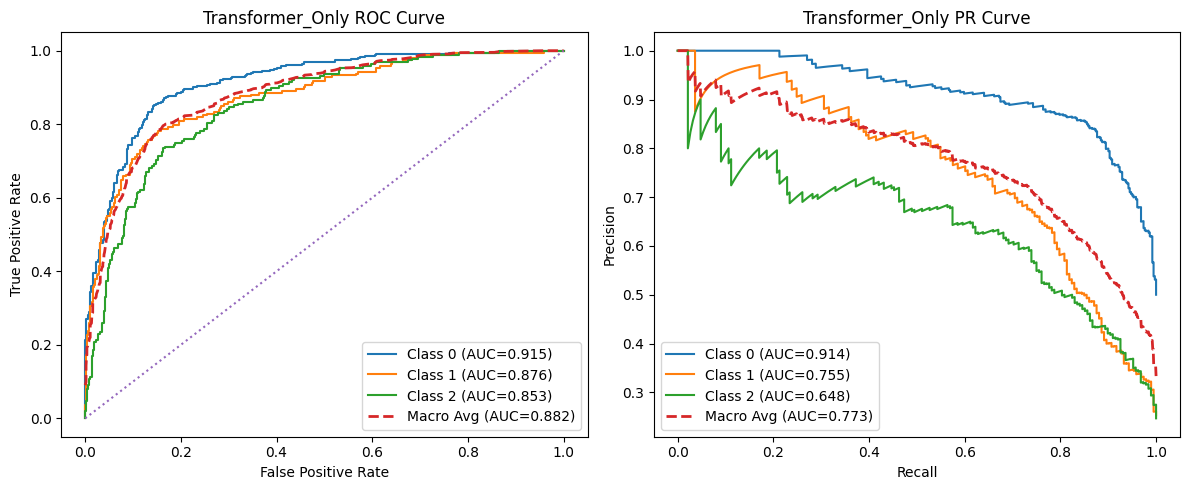


Ablation Study Summary
              Model  Train Accuracy  Test Accuracy  Train F1-Macro  \
0       Hybrid_Full        0.960604       0.914698        0.957146   
1          CNN_Only        0.819764       0.799213        0.795400   
2  Transformer_Only        0.892974       0.765092        0.879046   

   Test F1-Macro  Train Precision-Macro  Test Precision-Macro  \
0       0.908917               0.961216              0.912572   
1       0.767165               0.811218              0.778858   
2       0.732083               0.886086              0.735432   

   Train Recall-Macro  Test Recall-Macro  Train ROC-AUC  Test ROC-AUC  \
0            0.953420           0.905568       0.993370      0.971752   
1            0.784285           0.759047       0.935116      0.909566   
2            0.873005           0.730058       0.967472      0.881497   

   Train PR-AUC  Test PR-AUC  
0      0.988319     0.956627  
1      0.879589     0.831176  
2      0.934058     0.773269  


,Model,Train Accuracy,Test Accuracy,Train F1-Macro,Test F1-Macro,Train Precision-Macro,Test Precision-Macro,Train Recall-Macro,Test Recall-Macro,Train ROC-AUC,Test ROC-AUC,Train PR-AUC,Test PR-AUC
0,Hybrid_Full,0.960604,0.914698,0.957146,0.908917,0.961216,0.912572,0.953420,0.905568,0.993370,0.971752,0.988319,0.956627
1,CNN_Only,0.819764,0.799213,0.795400,0.767165,0.811218,0.778858,0.784285,0.759047,0.935116,0.909566,0.879589,0.831176
2,Transformer_Only,0.892974,0.765092,0.879046,0.732083,0.886086,0.735432,0.873005,0.730058,0.967472,0.881497,0.934058,0.773269


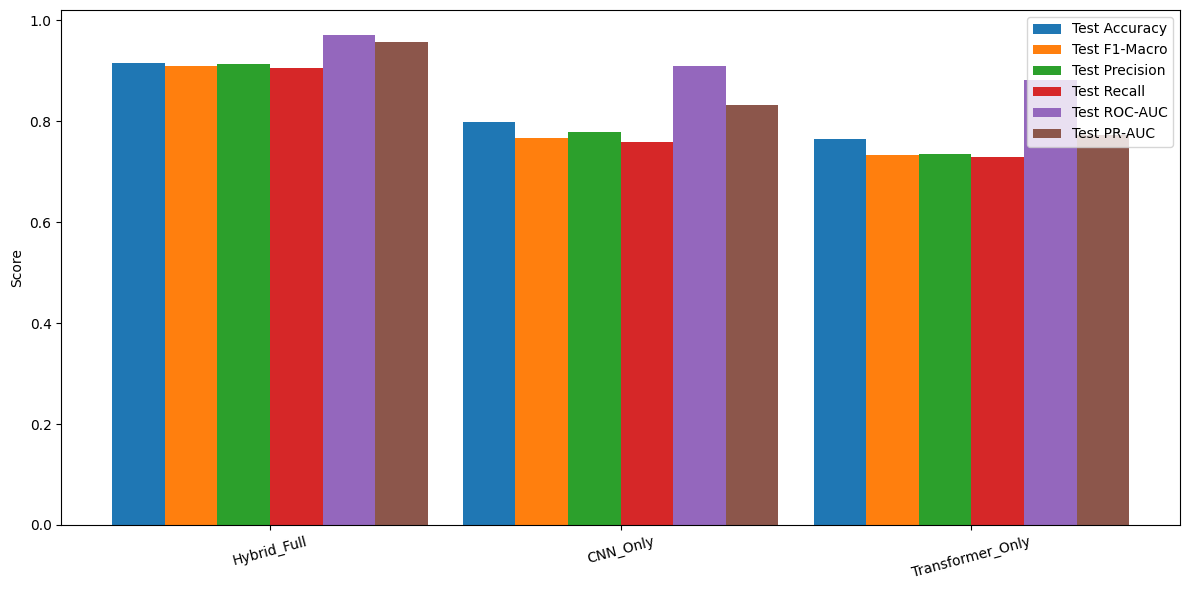


Performance Margin
Hybrid_Full - CNN_Only         : 0.1155
Hybrid_Full - Transformer_Only : 0.1496


In [1]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Conv1D, BatchNormalization,
    AveragePooling1D, Flatten, Add, LayerNormalization,
    MultiHeadAttention, GaussianNoise, Embedding
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_auc_score,
    average_precision_score, roc_curve, precision_recall_curve, auc,
    f1_score, precision_score, recall_score, classification_report
)

warnings.filterwarnings("ignore")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values.astype(int)

num_classes = len(np.unique(y))

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    shuffle=True,
    random_state=SEED
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

input_shape = X_train.shape[1:]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Classes    :", num_classes)

def add_learned_positional_encoding(x):
    seq_len = int(x.shape[1])
    embed_dim = int(x.shape[2])

    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_embedding_layer = Embedding(input_dim=seq_len, output_dim=embed_dim)
    pos_embedding = pos_embedding_layer(positions) 
    pos_embedding = tf.expand_dims(pos_embedding, axis=0)

    return x + pos_embedding


def transformer_encoder_block(x, num_heads=4, ff_dim=64, dropout_rate=0.6, l2_reg=0.3):
    embed_dim = int(x.shape[-1])

    attn = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim
    )(x, x)

    x = Add()([x, attn])
    x = LayerNormalization()(x)

    ff = Dense(ff_dim, activation='relu', kernel_regularizer=l2(l2_reg))(x)
    ff = Dropout(dropout_rate)(ff)
    ff = Dense(embed_dim, kernel_regularizer=l2(l2_reg))(ff)

    x = Add()([x, ff])
    x = LayerNormalization()(x)

    return x

def build_CT(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = GaussianNoise(0.01)(inputs)

    x = Conv1D(
        filters=8,
        kernel_size=64,
        strides=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    x = Conv1D(
        filters=16,
        kernel_size=16,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.3)
    )(x)
    x = BatchNormalization()(x)

    x = Conv1D(
        filters=16,
        kernel_size=1,
        strides=1,
        padding='same',
        activation='elu',
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    x = AveragePooling1D(pool_size=8)(x)
    x = Dropout(0.6)(x)

    x = add_learned_positional_encoding(x)

    x = transformer_encoder_block(
        x,
        num_heads=4,
        ff_dim=64,
        dropout_rate=0.6,
        l2_reg=0.3
    )

    x = Flatten()(x)
    outputs = Dense(
        num_classes,
        activation='softmax',
        kernel_regularizer=l2(0.2)
    )(x)

    model = Model(inputs, outputs, name="CTHM_with_PosEnc")
    model.compile(
        optimizer=Adam(learning_rate=5e-5, clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_cnn_only_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = GaussianNoise(0.01)(inputs)

    x = Conv1D(
        filters=8,
        kernel_size=64,
        strides=1,
        padding="same",
        activation="elu",
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    x = Conv1D(
        filters=16,
        kernel_size=16,
        padding="same",
        activation="elu",
        kernel_regularizer=l2(0.3)
    )(x)
    x = BatchNormalization()(x)

    x = Conv1D(
        filters=16,
        kernel_size=1,
        strides=1,
        padding="same",
        activation="elu",
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    x = AveragePooling1D(pool_size=8)(x)
    x = Dropout(0.6)(x)

    x = Flatten()(x)
    x = Dense(64, activation="relu", kernel_regularizer=l2(0.3))(x)
    x = Dropout(0.6)(x)

    outputs = Dense(
        num_classes,
        activation="softmax",
        kernel_regularizer=l2(0.2)
    )(x)

    model = Model(inputs, outputs, name="CNN_Only")
    model.compile(
        optimizer=Adam(learning_rate=5e-5, clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_transformer_only_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = GaussianNoise(0.01)(inputs)

    x = Conv1D(
        filters=16,
        kernel_size=1,
        padding="same",
        activation="elu",
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    x = AveragePooling1D(pool_size=8)(x) 
    x = Dropout(0.6)(x)

    x = add_learned_positional_encoding(x)

    x = transformer_encoder_block(
        x,
        num_heads=4,
        ff_dim=64,
        dropout_rate=0.6,
        l2_reg=0.3
    )

    x = Flatten()(x)

    outputs = Dense(
        num_classes,
        activation="softmax",
        kernel_regularizer=l2(0.2)
    )(x)

    model = Model(inputs, outputs, name="Transformer_Only")
    model.compile(
        optimizer=Adam(learning_rate=5e-5, clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def compute_auc_metrics(y_true, y_prob, num_classes):
    y_true_bin = to_categorical(y_true, num_classes=num_classes)

    if num_classes == 2:
        roc_auc = roc_auc_score(y_true, y_prob[:, 1])
        pr_auc = average_precision_score(y_true, y_prob[:, 1])
    else:
        roc_auc = roc_auc_score(
            y_true_bin, y_prob,
            multi_class="ovr",
            average="macro"
        )
        pr_auc = average_precision_score(
            y_true_bin, y_prob,
            average="macro"
        )

    return roc_auc, pr_auc


def compute_all_metrics(y_true, y_prob, num_classes):
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    roc_auc, pr_auc = compute_auc_metrics(y_true, y_prob, num_classes)

    return {
        "Accuracy": acc,
        "F1-Macro": f1,
        "Precision-Macro": precision,
        "Recall-Macro": recall,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Predictions": y_pred
    }

def plot_conf_matrix(y_true, y_pred, model_name, num_classes):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=range(num_classes),
        yticklabels=range(num_classes)
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Val Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


def plot_roc_pr_curves(y_true, y_prob, num_classes, model_name):
    y_true_bin = to_categorical(y_true, num_classes=num_classes)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)

    fpr_dict = {}
    tpr_dict = {}

    for i in range(num_classes):
        fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc_i = auc(fpr_dict[i], tpr_dict[i])
        plt.plot(
            fpr_dict[i], tpr_dict[i],
            label=f"Class {i} (AUC={roc_auc_i:.3f})"
        )

    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(num_classes)]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(num_classes):
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])

    mean_tpr /= num_classes
    macro_roc_auc = auc(all_fpr, mean_tpr)

    plt.plot(
        all_fpr, mean_tpr,
        linestyle="--", linewidth=2,
        label=f"Macro Avg (AUC={macro_roc_auc:.3f})"
    )

    plt.plot([0, 1], [0, 1], linestyle=":")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} ROC Curve")
    plt.legend()

    plt.subplot(1, 2, 2)

    precision_dict = {}
    recall_dict = {}

    for i in range(num_classes):
        precision_dict[i], recall_dict[i], _ = precision_recall_curve(
            y_true_bin[:, i], y_prob[:, i]
        )
        pr_auc_i = auc(recall_dict[i], precision_dict[i])
        plt.plot(
            recall_dict[i], precision_dict[i],
            label=f"Class {i} (AUC={pr_auc_i:.3f})"
        )

    recall_grid = np.linspace(0.0, 1.0, 1000)
    mean_precision = np.zeros_like(recall_grid)

    for i in range(num_classes):
        recall_i = recall_dict[i][::-1]
        precision_i = precision_dict[i][::-1]
        interp_precision = np.interp(recall_grid, recall_i, precision_i)
        mean_precision += interp_precision

    mean_precision /= num_classes

    macro_pr_auc = average_precision_score(
        y_true_bin,
        y_prob,
        average="macro"
    )

    plt.plot(
        recall_grid, mean_precision,
        linestyle="--", linewidth=2,
        label=f"Macro Avg (AUC={macro_pr_auc:.3f})"
    )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name} PR Curve")
    plt.legend()

    plt.tight_layout()
    plt.show()

def train_and_evaluate(model_fn, model_name, X_train, y_train, X_test, y_test, num_classes):
    print("\n" + "=" * 80)
    print(f"Training {model_name}")
    print("=" * 80)

    model = model_fn(input_shape, num_classes)
    model.summary()

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    )

    lr_scheduler = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=500,
        batch_size=32,
        callbacks=[early_stopping, lr_scheduler],
        verbose=1
    )

    y_train_prob = model.predict(X_train, verbose=0)
    y_test_prob = model.predict(X_test, verbose=0)

    train_metrics = compute_all_metrics(y_train, y_train_prob, num_classes)
    test_metrics = compute_all_metrics(y_test, y_test_prob, num_classes)

    print(f"\n{model_name} Results")
    print(f"Train Accuracy        : {train_metrics['Accuracy']:.4f}")
    print(f"Test Accuracy         : {test_metrics['Accuracy']:.4f}")
    print(f"Train F1-Macro        : {train_metrics['F1-Macro']:.4f}")
    print(f"Test F1-Macro         : {test_metrics['F1-Macro']:.4f}")
    print(f"Train Precision-Macro : {train_metrics['Precision-Macro']:.4f}")
    print(f"Test Precision-Macro  : {test_metrics['Precision-Macro']:.4f}")
    print(f"Train Recall-Macro    : {train_metrics['Recall-Macro']:.4f}")
    print(f"Test Recall-Macro     : {test_metrics['Recall-Macro']:.4f}")
    print(f"Train ROC-AUC         : {train_metrics['ROC-AUC']:.4f}")
    print(f"Test ROC-AUC          : {test_metrics['ROC-AUC']:.4f}")
    print(f"Train PR-AUC          : {train_metrics['PR-AUC']:.4f}")
    print(f"Test PR-AUC           : {test_metrics['PR-AUC']:.4f}")

    print("\nClassification Report (Test Data):")
    print(classification_report(y_test, test_metrics["Predictions"]))

    plot_conf_matrix(y_test, test_metrics["Predictions"], model_name, num_classes)
    plot_training_history(history, model_name)
    plot_roc_pr_curves(y_test, y_test_prob, num_classes, model_name)

    results = {
        "Model": model_name,
        "Train Accuracy": train_metrics["Accuracy"],
        "Test Accuracy": test_metrics["Accuracy"],
        "Train F1-Macro": train_metrics["F1-Macro"],
        "Test F1-Macro": test_metrics["F1-Macro"],
        "Train Precision-Macro": train_metrics["Precision-Macro"],
        "Test Precision-Macro": test_metrics["Precision-Macro"],
        "Train Recall-Macro": train_metrics["Recall-Macro"],
        "Test Recall-Macro": test_metrics["Recall-Macro"],
        "Train ROC-AUC": train_metrics["ROC-AUC"],
        "Test ROC-AUC": test_metrics["ROC-AUC"],
        "Train PR-AUC": train_metrics["PR-AUC"],
        "Test PR-AUC": test_metrics["PR-AUC"]
    }

    return model, history, results

all_results = []

hybrid_model, hybrid_history, hybrid_results = train_and_evaluate(
    build_CT, "Hybrid_Full",
    X_train, y_train, X_test, y_test, num_classes
)
all_results.append(hybrid_results)

cnn_model, cnn_history, cnn_results = train_and_evaluate(
    build_cnn_only_model, "CNN_Only",
    X_train, y_train, X_test, y_test, num_classes
)
all_results.append(cnn_results)

transformer_model, transformer_history, transformer_results = train_and_evaluate(
    build_transformer_only_model, "Transformer_Only",
    X_train, y_train, X_test, y_test, num_classes
)
all_results.append(transformer_results)

results_df = pd.DataFrame(all_results)

print("\n" + "=" * 80)
print("Ablation Study Summary")
print("=" * 80)
print(results_df)

display(results_df)

plt.figure(figsize=(12, 6))
x = np.arange(len(results_df["Model"]))
width = 0.15

plt.bar(x - 2.5 * width, results_df["Test Accuracy"], width=width, label="Test Accuracy")
plt.bar(x - 1.5 * width, results_df["Test F1-Macro"], width=width, label="Test F1-Macro")
plt.bar(x - 0.5 * width, results_df["Test Precision-Macro"], width=width, label="Test Precision")
plt.bar(x + 0.5 * width, results_df["Test Recall-Macro"], width=width, label="Test Recall")
plt.bar(x + 1.5 * width, results_df["Test ROC-AUC"], width=width, label="Test ROC-AUC")
plt.bar(x + 2.5 * width, results_df["Test PR-AUC"], width=width, label="Test PR-AUC")

plt.xticks(x, results_df["Model"], rotation=15)
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

hybrid_acc = results_df.loc[results_df["Model"] == "Hybrid_Full", "Test Accuracy"].values[0]
cnn_acc = results_df.loc[results_df["Model"] == "CNN_Only", "Test Accuracy"].values[0]
trans_acc = results_df.loc[results_df["Model"] == "Transformer_Only", "Test Accuracy"].values[0]

print("\n" + "=" * 80)
print("Performance Margin")
print("=" * 80)
print(f"Hybrid_Full - CNN_Only         : {hybrid_acc - cnn_acc:.4f}")
print(f"Hybrid_Full - Transformer_Only : {hybrid_acc - trans_acc:.4f}")

In [2]:
### CV

In [8]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Conv1D, BatchNormalization,
    AveragePooling1D, Flatten, Add, LayerNormalization,
    MultiHeadAttention, GaussianNoise, Embedding
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

warnings.filterwarnings("ignore")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values.astype(int)

num_classes = len(np.unique(y))

print("Full data shape:", X.shape)
print("Classes        :", num_classes)

def add_learned_positional_encoding(x):
    seq_len = int(x.shape[1])
    embed_dim = int(x.shape[2])

    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_embedding_layer = Embedding(input_dim=seq_len, output_dim=embed_dim)
    pos_embedding = pos_embedding_layer(positions)
    pos_embedding = tf.expand_dims(pos_embedding, axis=0)

    return x + pos_embedding


def transformer_encoder_block(x, num_heads=4, ff_dim=64, dropout_rate=0.6, l2_reg=0.3):
    embed_dim = int(x.shape[-1])

    attn = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim
    )(x, x)

    x = Add()([x, attn])
    x = LayerNormalization()(x)

    ff = Dense(
        ff_dim,
        activation="relu",
        kernel_regularizer=l2(l2_reg)
    )(x)
    ff = Dropout(dropout_rate)(ff)
    ff = Dense(
        embed_dim,
        kernel_regularizer=l2(l2_reg)
    )(ff)

    x = Add()([x, ff])
    x = LayerNormalization()(x)

    return x

def build_CTHM(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = GaussianNoise(0.01)(inputs)

    x = Conv1D(
        filters=8,
        kernel_size=64,
        strides=1,
        padding="same",
        activation="elu",
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    x = Conv1D(
        filters=16,
        kernel_size=16,
        padding="same",
        activation="elu",
        kernel_regularizer=l2(0.3)
    )(x)
    x = BatchNormalization()(x)

    x = Conv1D(
        filters=16,
        kernel_size=1,
        strides=1,
        padding="same",
        activation="elu",
        kernel_regularizer=l2(0.2)
    )(x)
    x = BatchNormalization()(x)

    x = AveragePooling1D(pool_size=8)(x)
    x = Dropout(0.6)(x)

    x = add_learned_positional_encoding(x)

    x = transformer_encoder_block(
        x,
        num_heads=4,
        ff_dim=64,
        dropout_rate=0.6,
        l2_reg=0.3
    )

    x = Flatten()(x)

    outputs = Dense(
        num_classes,
        activation="softmax",
        kernel_regularizer=l2(0.2)
    )(x)

    model = Model(inputs, outputs, name="CTHM")
    model.compile(
        optimizer=Adam(learning_rate=5e-5, clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def train_and_evaluate_fold(X_train, y_train, X_test, y_test, num_classes):
    input_shape = X_train.shape[1:]
    model = build_CTHM(input_shape, num_classes)

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=0
    )

    lr_scheduler = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=0
    )

    model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=500,
        batch_size=32,
        callbacks=[early_stopping, lr_scheduler],
        verbose=0
    )

    y_test_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    test_acc = accuracy_score(y_test, y_test_pred)

    return test_acc

K = 10
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED)

fold_accuracies = []

for fold_no, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    tf.keras.backend.clear_session()

    X_train_raw, X_test_raw = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    X_train = np.expand_dims(X_train, axis=-1)
    X_test = np.expand_dims(X_test, axis=-1)

    test_acc = train_and_evaluate_fold(
        X_train, y_train, X_test, y_test, num_classes
    )

    fold_accuracies.append(test_acc)
    print(f"Fold {fold_no} Test Accuracy: {test_acc:.4f}")

fold_accuracies = np.array(fold_accuracies)

mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies, ddof=1)

print("\n" + "=" * 60)
print("10-Fold Cross-Validation Results (CTHM)")
print("=" * 60)
print(f"Mean Accuracy : {mean_acc:.4f}")
print(f"Std Dev       : {std_acc:.4f}")


results_df = pd.DataFrame({
    "Fold": np.arange(1, K + 1),
    "Test Accuracy": fold_accuracies
})

print("\nPer-Fold Test Accuracy")
print(results_df)

summary_df = pd.DataFrame({
    "Metric": ["Mean Accuracy", "Std Accuracy"],
    "Value": [mean_acc, std_acc]
})

print("\nSummary")
print(summary_df)

Full data shape: (3808, 3800)
Classes        : 3
Fold 1 Test Accuracy: 0.9003
Fold 2 Test Accuracy: 0.8845
Fold 3 Test Accuracy: 0.9134
Fold 4 Test Accuracy: 0.8793
Fold 5 Test Accuracy: 0.9003
Fold 6 Test Accuracy: 0.9265
Fold 7 Test Accuracy: 0.9186
Fold 8 Test Accuracy: 0.9108
Fold 9 Test Accuracy: 0.8947
Fold 10 Test Accuracy: 0.9211

10-Fold Cross-Validation Results (CTHM)
Mean Accuracy : 0.9049
Std Dev       : 0.0158

Per-Fold Test Accuracy
   Fold  Test Accuracy
0     1       0.900262
1     2       0.884514
2     3       0.913386
3     4       0.879265
4     5       0.900262
5     6       0.926509
6     7       0.918635
7     8       0.910761
8     9       0.894737
9    10       0.921053

Summary
          Metric     Value
0  Mean Accuracy  0.904939
1   Std Accuracy  0.015783


### XGBoost

Full data shape: (3808, 3800)
Classes        : 3
Train shape: (3046, 3800)
Test shape : (762, 3800)

Training XGBoost

XGBoost Results
Train Accuracy        : 0.9905
Test Accuracy         : 0.8609
Train F1-Macro        : 0.9902
Test F1-Macro         : 0.8439
Train Precision-Macro : 0.9933
Test Precision-Macro  : 0.8727
Train Recall-Macro    : 0.9873
Test Recall-Macro     : 0.8257
Train ROC-AUC         : 0.9999
Test ROC-AUC          : 0.9558
Train PR-AUC          : 0.9999
Test PR-AUC           : 0.9231

Classification Report (Test Data):
              precision    recall  f1-score   support

           0     0.8402    0.9659    0.8987       381
           1     0.8882    0.7824    0.8320       193
           2     0.8896    0.7287    0.8012       188

    accuracy                         0.8609       762
   macro avg     0.8727    0.8257    0.8439       762
weighted avg     0.8645    0.8609    0.8577       762


Per-class One-vs-Rest ROC-AUC and PR-AUC:
Class 0: ROC-AUC=0.9592, PR-AUC=0

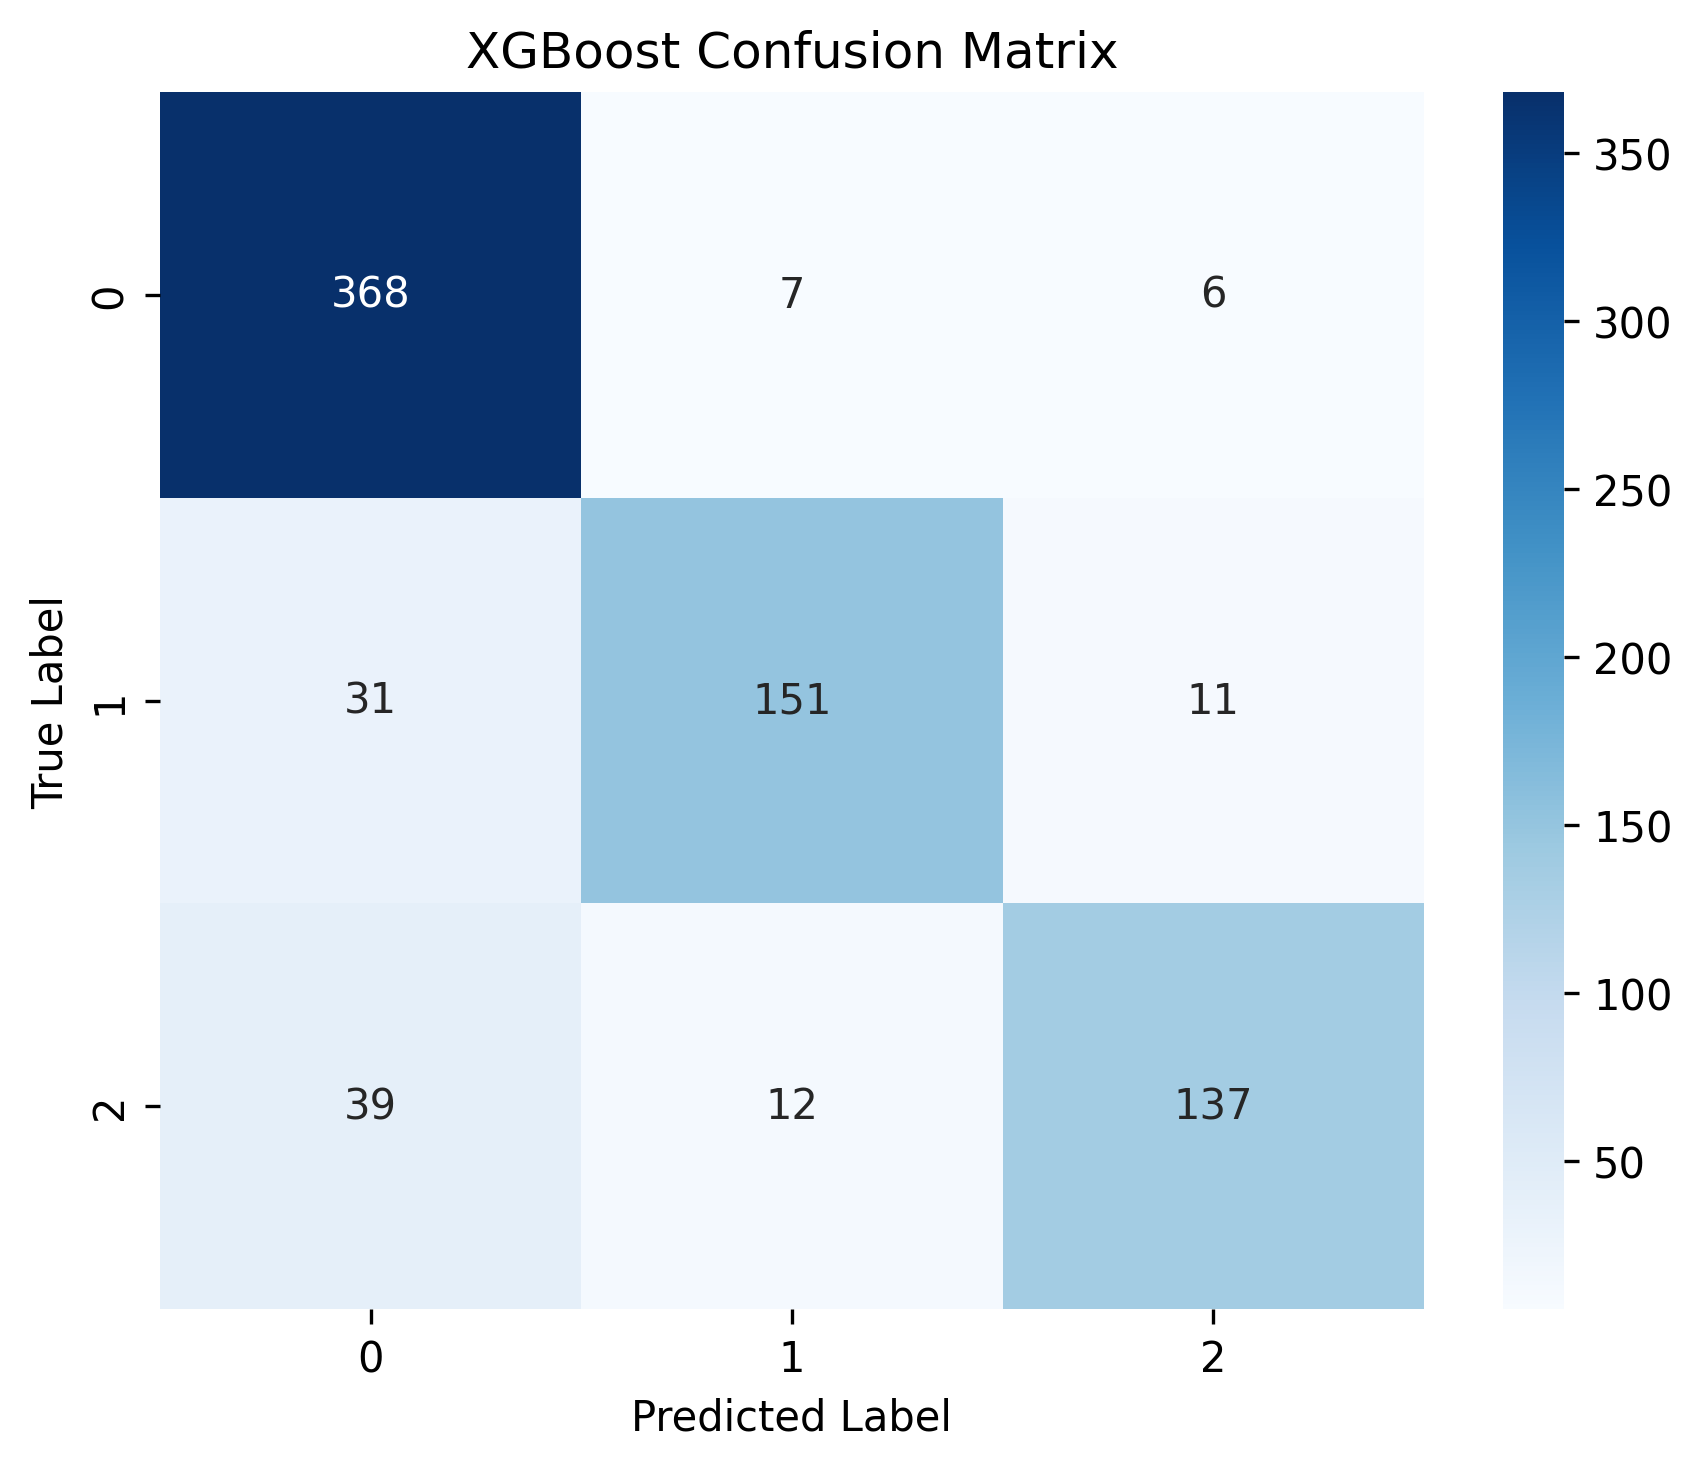

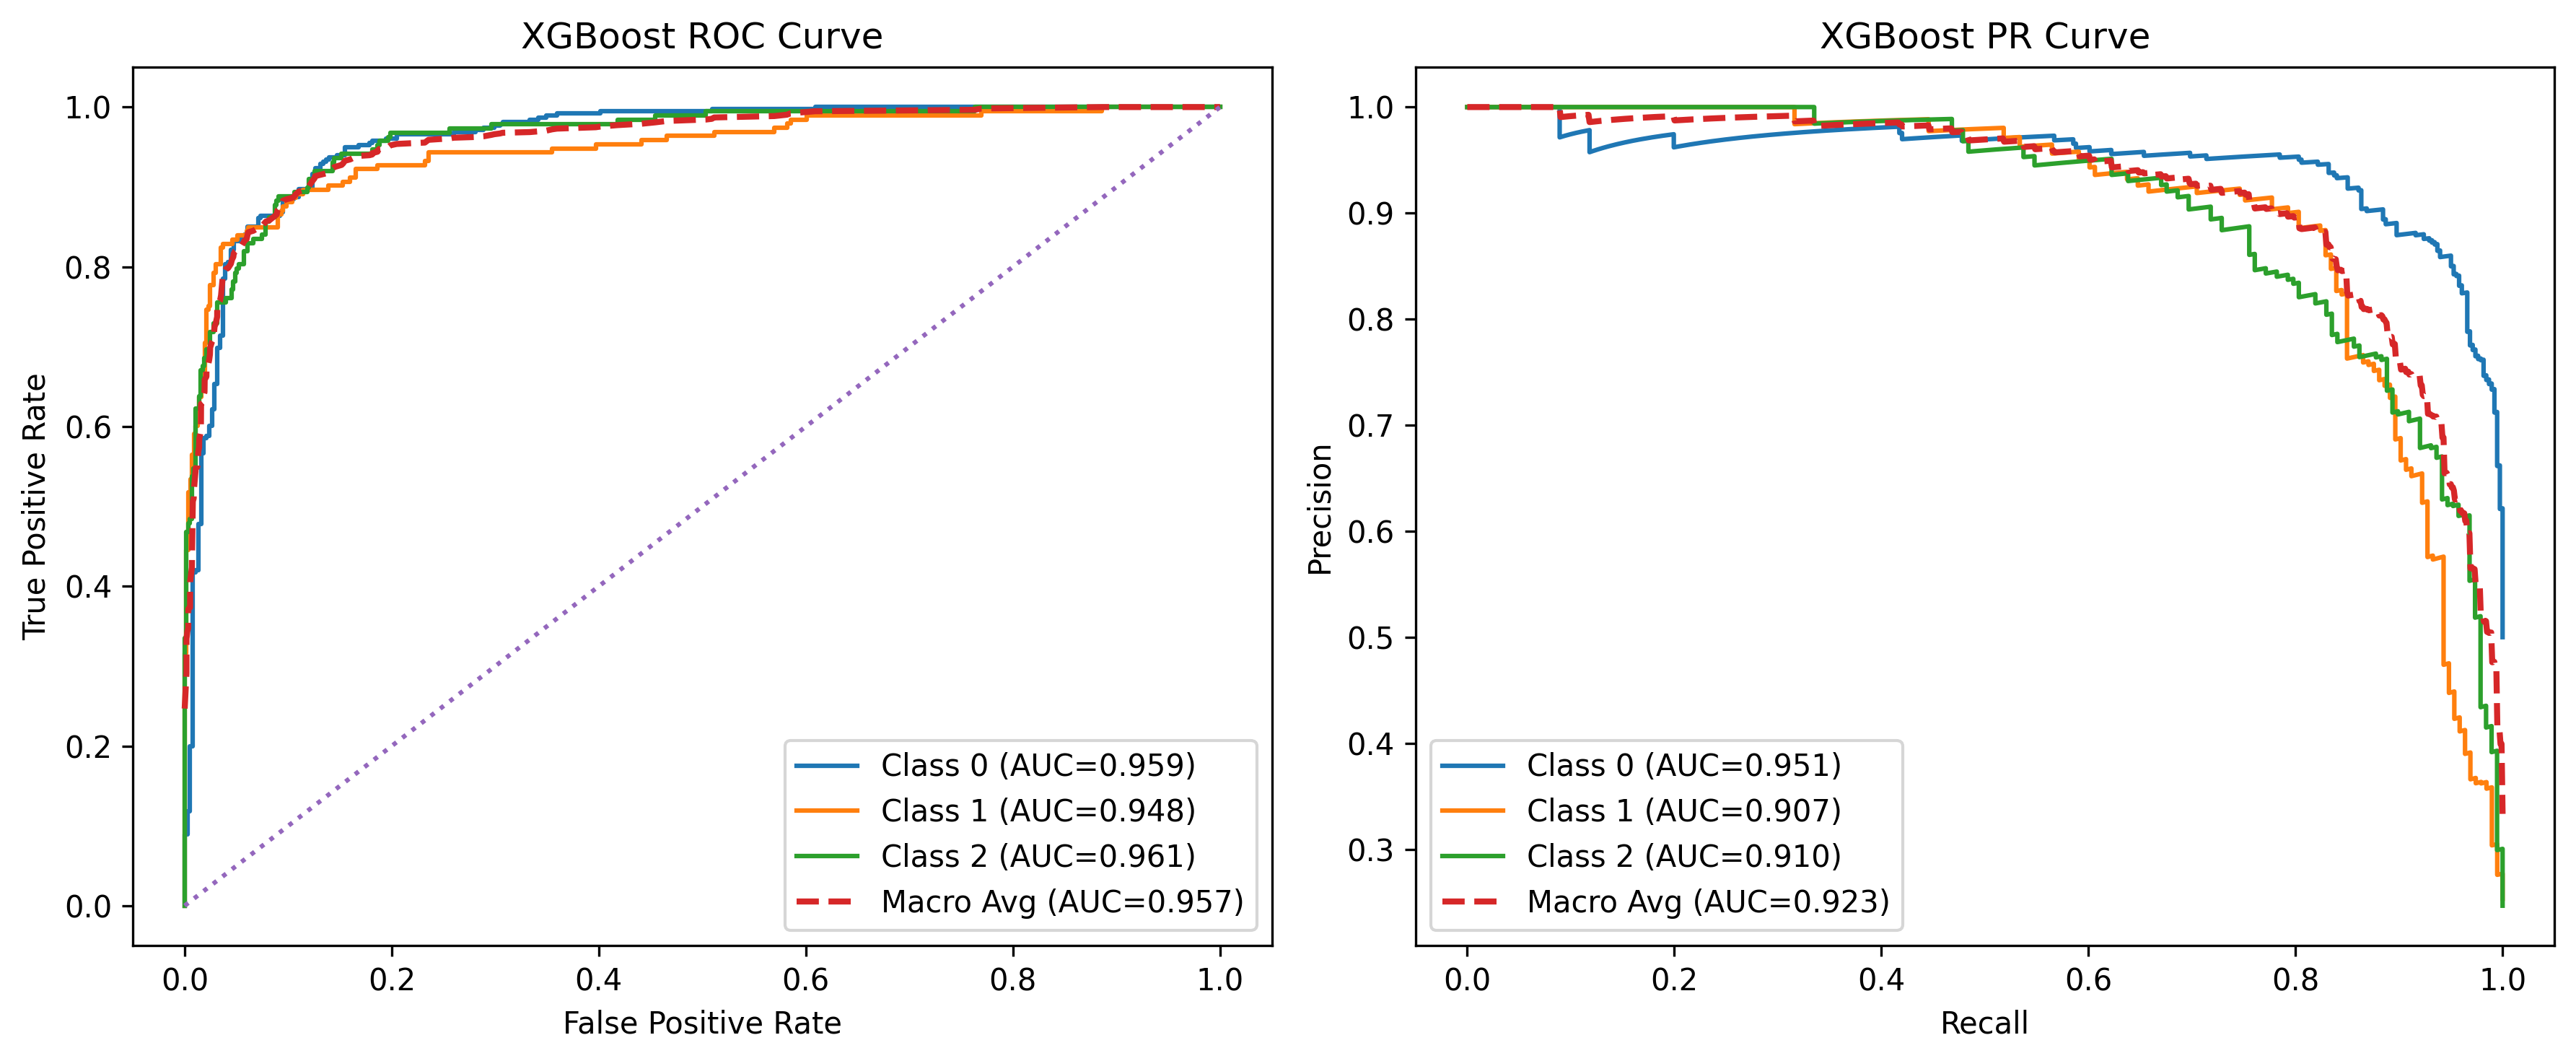

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    auc,
    f1_score,
    precision_score,
    recall_score
)

SEED = 42
np.random.seed(SEED)

dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values.astype(int)

num_classes = len(np.unique(y))

print("Full data shape:", X.shape)
print("Classes        :", num_classes)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    shuffle=True,
    random_state=SEED
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

xgb_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,
    learning_rate=0.01,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    eval_metric="mlogloss"
)

print("\n" + "=" * 80)
print("Training XGBoost")
print("=" * 80)

xgb_model.fit(X_train, y_train)

y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

y_train_prob = xgb_model.predict_proba(X_train)
y_test_prob = xgb_model.predict_proba(X_test)

def compute_auc_metrics(y_true, y_prob, num_classes):
    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

    if num_classes == 2:
        roc_auc = roc_auc_score(y_true, y_prob[:, 1])
        pr_auc = average_precision_score(y_true, y_prob[:, 1])
    else:
        roc_auc = roc_auc_score(
            y_true_bin,
            y_prob,
            multi_class="ovr",
            average="macro"
        )
        pr_auc = average_precision_score(
            y_true_bin,
            y_prob,
            average="macro"
        )

    return roc_auc, pr_auc


def compute_all_metrics(y_true, y_prob, num_classes):
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    roc_auc, pr_auc = compute_auc_metrics(y_true, y_prob, num_classes)

    return {
        "Accuracy": acc,
        "F1-Macro": f1,
        "Precision-Macro": precision,
        "Recall-Macro": recall,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Predictions": y_pred
    }

def plot_conf_matrix(y_true, y_pred, model_name, num_classes):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5), dpi=300)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=range(num_classes),
        yticklabels=range(num_classes)
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.show()


def plot_roc_pr_curves(y_true, y_prob, num_classes, model_name):
    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

    plt.figure(figsize=(12, 5), dpi=300)

    plt.subplot(1, 2, 1)

    fpr_dict = {}
    tpr_dict = {}

    for i in range(num_classes):
        fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc_i = auc(fpr_dict[i], tpr_dict[i])
        plt.plot(
            fpr_dict[i], tpr_dict[i],
            label=f"Class {i} (AUC={roc_auc_i:.3f})"
        )

    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(num_classes)]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(num_classes):
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])

    mean_tpr /= num_classes
    macro_roc_auc = auc(all_fpr, mean_tpr)

    plt.plot(
        all_fpr, mean_tpr,
        linestyle="--", linewidth=2,
        label=f"Macro Avg (AUC={macro_roc_auc:.3f})"
    )

    plt.plot([0, 1], [0, 1], linestyle=":")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()


    plt.subplot(1, 2, 2)

    precision_dict = {}
    recall_dict = {}

    for i in range(num_classes):
        precision_dict[i], recall_dict[i], _ = precision_recall_curve(
            y_true_bin[:, i], y_prob[:, i]
        )
        pr_auc_i = auc(recall_dict[i], precision_dict[i])
        plt.plot(
            recall_dict[i], precision_dict[i],
            label=f"Class {i} (AUC={pr_auc_i:.3f})"
        )

    recall_grid = np.linspace(0.0, 1.0, 1000)
    mean_precision = np.zeros_like(recall_grid)

    for i in range(num_classes):
        recall_i = recall_dict[i][::-1]
        precision_i = precision_dict[i][::-1]
        interp_precision = np.interp(recall_grid, recall_i, precision_i)
        mean_precision += interp_precision

    mean_precision /= num_classes

    macro_pr_auc = average_precision_score(
        y_true_bin,
        y_prob,
        average="macro"
    )

    plt.plot(
        recall_grid, mean_precision,
        linestyle="--", linewidth=2,
        label=f"Macro Avg (AUC={macro_pr_auc:.3f})"
    )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()

    plt.tight_layout()
    plt.show()


def plot_feature_importance(model, max_num_features=15):
    plt.figure(figsize=(10, 5), dpi=300)
    xgb.plot_importance(
        model,
        importance_type="weight",
        max_num_features=max_num_features
    )
    plt.title("Top 15 Feature Importances - XGBoost")
    plt.tight_layout()
    plt.show()

train_metrics = compute_all_metrics(y_train, y_train_prob, num_classes)
test_metrics = compute_all_metrics(y_test, y_test_prob, num_classes)

print(f"\nXGBoost Results")
print(f"Train Accuracy        : {train_metrics['Accuracy']:.4f}")
print(f"Test Accuracy         : {test_metrics['Accuracy']:.4f}")
print(f"Train F1-Macro        : {train_metrics['F1-Macro']:.4f}")
print(f"Test F1-Macro         : {test_metrics['F1-Macro']:.4f}")
print(f"Train Precision-Macro : {train_metrics['Precision-Macro']:.4f}")
print(f"Test Precision-Macro  : {test_metrics['Precision-Macro']:.4f}")
print(f"Train Recall-Macro    : {train_metrics['Recall-Macro']:.4f}")
print(f"Test Recall-Macro     : {test_metrics['Recall-Macro']:.4f}")
print(f"Train ROC-AUC         : {train_metrics['ROC-AUC']:.4f}")
print(f"Test ROC-AUC          : {test_metrics['ROC-AUC']:.4f}")
print(f"Train PR-AUC          : {train_metrics['PR-AUC']:.4f}")
print(f"Test PR-AUC           : {test_metrics['PR-AUC']:.4f}")

print("\nClassification Report (Test Data):")
print(classification_report(y_test, test_metrics["Predictions"], digits=4))

print("\nPer-class One-vs-Rest ROC-AUC and PR-AUC:")

y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))

for i in range(num_classes):
    roc_auc_i = roc_auc_score(y_test_bin[:, i], y_test_prob[:, i])
    pr_auc_i = average_precision_score(y_test_bin[:, i], y_test_prob[:, i])
    print(f"Class {i}: ROC-AUC={roc_auc_i:.4f}, PR-AUC={pr_auc_i:.4f}")

plot_conf_matrix(y_test, test_metrics["Predictions"], "XGBoost", num_classes)
plot_roc_pr_curves(y_test, y_test_prob, num_classes, "XGBoost")


### EEGNet

Full data shape: (3808, 3800)
Classes        : 3
Reshaped data  : (3808, 19, 200, 1)
Epoch 1/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 322ms/step - accuracy: 0.3251 - loss: 1.1340 - val_accuracy: 0.3754 - val_loss: 1.0979
Epoch 2/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3521 - loss: 1.0972 - val_accuracy: 0.4279 - val_loss: 1.0967
Epoch 3/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3771 - loss: 1.0890 - val_accuracy: 0.4443 - val_loss: 1.0952
Epoch 4/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4202 - loss: 1.0795 - val_accuracy: 0.4770 - val_loss: 1.0933
Epoch 5/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4520 - loss: 1.0714 - val_accuracy: 0.4984 - val_loss: 1.0910
Epoch 6/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4761 - loss: 1.0646 - val_accuracy: 0.5033 - val_loss: 1.0881
Epoch 7/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4834 - loss: 1.0596 - val_accuracy: 0.5164 - val_loss: 1.0845
Epoch 8/250
20/20

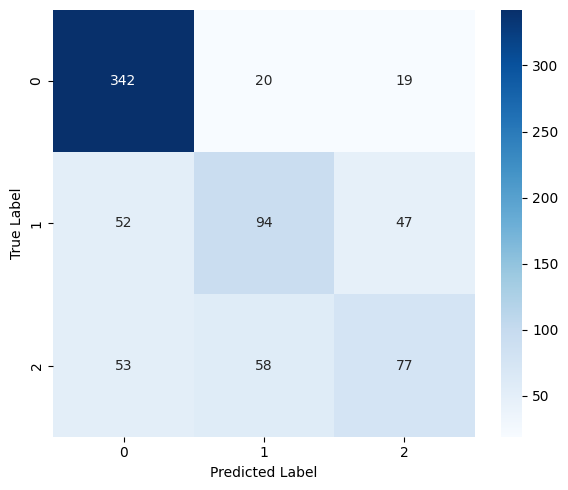

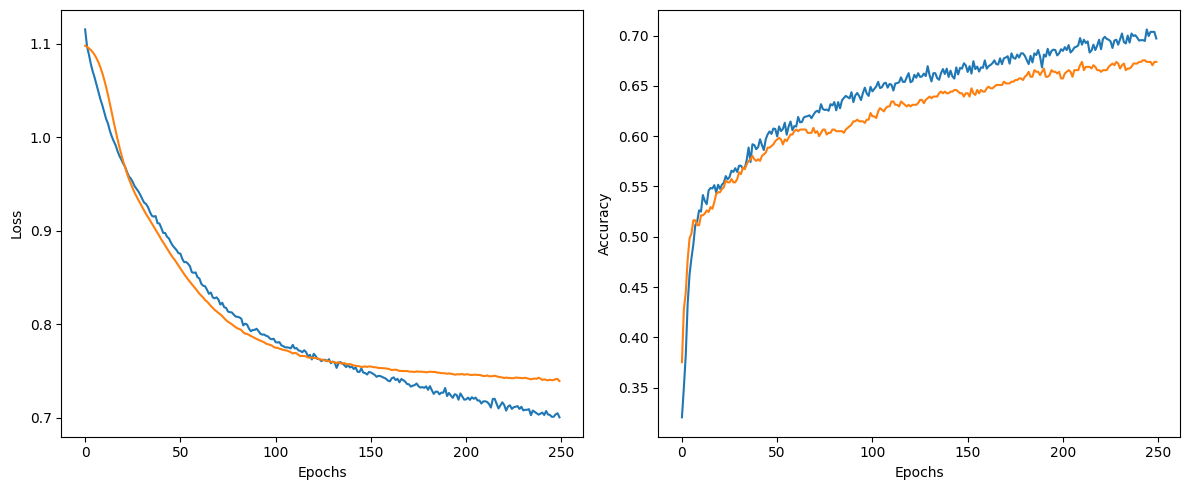

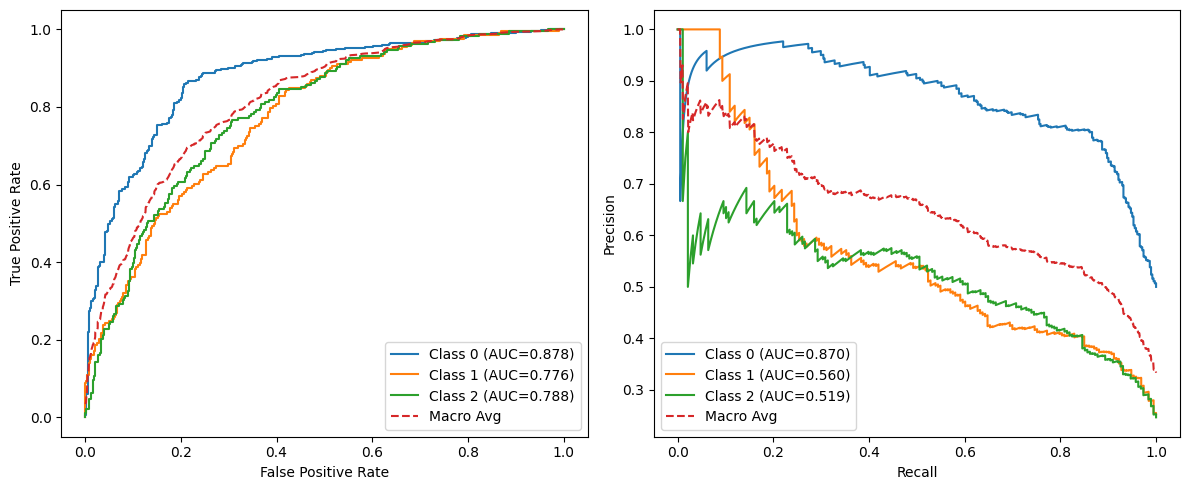

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Flatten, Conv2D, DepthwiseConv2D,
    SeparableConv2D, BatchNormalization, Activation, AveragePooling2D, Lambda
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    auc,
    f1_score,
    precision_score,
    recall_score
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"

df = pd.read_csv(dataset_path, header=None)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values.astype(int)

num_classes = len(np.unique(y))

print("Full data shape:", X.shape)
print("Classes        :", num_classes)

scaler = StandardScaler()
X = scaler.fit_transform(X)

channels = 19
time_points = X.shape[1] // channels
X = X.reshape(-1, channels, time_points, 1)

print("Reshaped data  :", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    shuffle=True,
    random_state=SEED
)

def EEGNet(nb_classes, Chans=19, Samples=200):
    inputs = Input(shape=(Chans, Samples, 1))

    x = Conv2D(8, (1, 64), padding='same', use_bias=False)(inputs)
    x = BatchNormalization()(x)

    x = DepthwiseConv2D(
        (Chans, 1),
        use_bias=False,
        depth_multiplier=2,
        depthwise_constraint=tf.keras.constraints.MaxNorm(1.)
    )(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = AveragePooling2D((1, 4))(x)
    x = Dropout(0.1)(x)

    x = SeparableConv2D(16, (1, 16), use_bias=False, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = AveragePooling2D((1, 8))(x)
    x = Dropout(0.1)(x)

    x = Flatten()(x)
    x = Dense(nb_classes, kernel_constraint=tf.keras.constraints.MaxNorm(0.25))(x)
    outputs = Activation('softmax')(x)

    return Model(inputs, outputs)


def compute_auc_metrics(y_true, y_prob, num_classes):
    y_true_bin = to_categorical(y_true, num_classes)

    roc_auc = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="macro")
    pr_auc = average_precision_score(y_true_bin, y_prob, average="macro")

    return roc_auc, pr_auc


def compute_all_metrics(y_true, y_prob, num_classes):
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    roc_auc, pr_auc = compute_auc_metrics(y_true, y_prob, num_classes)

    return {
        "Accuracy": acc,
        "F1-Macro": f1,
        "Precision-Macro": precision,
        "Recall-Macro": recall,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Predictions": y_pred
    }

def plot_conf_matrix(y_true, y_pred, num_classes):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=range(num_classes),
        yticklabels=range(num_classes)
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["loss"])
    plt.plot(history.history["val_loss"])
    plt.xlabel("Epochs")
    plt.ylabel("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(history.history["accuracy"])
    plt.plot(history.history["val_accuracy"])
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")

    plt.tight_layout()
    plt.show()


def plot_roc_pr_curves(y_true, y_prob, num_classes):
    y_true_bin = to_categorical(y_true, num_classes)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    fpr_dict, tpr_dict = {}, {}

    for i in range(num_classes):
        fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc_i = auc(fpr_dict[i], tpr_dict[i])
        plt.plot(fpr_dict[i], tpr_dict[i], label=f"Class {i} (AUC={roc_auc_i:.3f})")

    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(num_classes)]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(num_classes):
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])

    mean_tpr /= num_classes
    plt.plot(all_fpr, mean_tpr, linestyle="--", label="Macro Avg")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

    plt.subplot(1, 2, 2)
    precision_dict, recall_dict = {}, {}

    for i in range(num_classes):
        precision_dict[i], recall_dict[i], _ = precision_recall_curve(
            y_true_bin[:, i], y_prob[:, i]
        )
        pr_auc_i = auc(recall_dict[i], precision_dict[i])
        plt.plot(recall_dict[i], precision_dict[i], label=f"Class {i} (AUC={pr_auc_i:.3f})")

    recall_grid = np.linspace(0, 1, 1000)
    mean_precision = np.zeros_like(recall_grid)

    for i in range(num_classes):
        recall_i = recall_dict[i][::-1]
        precision_i = precision_dict[i][::-1]
        mean_precision += np.interp(recall_grid, recall_i, precision_i)

    mean_precision /= num_classes
    plt.plot(recall_grid, mean_precision, linestyle="--", label="Macro Avg")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()

    plt.tight_layout()
    plt.show()

model = EEGNet(num_classes, channels, time_points)

model.compile(
    optimizer=Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=250,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

y_train_prob = model.predict(X_train, verbose=0)
y_test_prob = model.predict(X_test, verbose=0)

train_metrics = compute_all_metrics(y_train, y_train_prob, num_classes)
test_metrics = compute_all_metrics(y_test, y_test_prob, num_classes)

print("\nEEGNet Results")
print(f"Train Accuracy : {train_metrics['Accuracy']:.4f}")
print(f"Test Accuracy  : {test_metrics['Accuracy']:.4f}")
print(f"Test ROC-AUC   : {test_metrics['ROC-AUC']:.4f}")
print(f"Test PR-AUC    : {test_metrics['PR-AUC']:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, test_metrics["Predictions"], digits=4))

plot_conf_matrix(y_test, test_metrics["Predictions"], num_classes)
plot_training_history(history)
plot_roc_pr_curves(y_test, y_test_prob, num_classes)

#### Transformer-based

Full data shape: (3808, 3800)
Classes        : 3
X_train shape: (3046, 1, 3800)
X_test shape : (762, 1, 3800)
Number of classes: 3


Model: "Transformer_Only"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 1, 3800)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1, 32)          │       121,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_7 (Add)                     │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 1, 32)          │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ (None, 1, 32)          │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_6             │ (None, 1, 32)          │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_7             │ (None, 1, 32)          │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,211 (805.51 KB)

 Trainable params: 206,211 (805.51 KB)

 Non-trainable params: 0 (0.00 B)


Training Transformer_Only
Epoch 1/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 557ms/step - accuracy: 0.3992 - loss: 22.4297 - val_accuracy: 0.5984 - val_loss: 21.4757
Epoch 2/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4554 - loss: 21.9237 - val_accuracy: 0.6230 - val_loss: 21.0513
Epoch 3/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4704 - loss: 21.5419 - val_accuracy: 0.6738 - val_loss: 20.6724
Epoch 4/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4847 - loss: 21.1941 - val_accuracy: 0.7016 - val_loss: 20.3056
Epoch 5/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5010 - loss: 20.8185 - val_accuracy: 0.7295 - val_loss: 19.9787
Epoch 6/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5371 - loss: 20.4306 - val_accuracy: 0.7328 - val_loss: 19.6807
Epoch 7/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5353 - loss: 20.1195 - val_accuracy: 0.7574 - val_loss: 19.3727
Epoch 8/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accurac

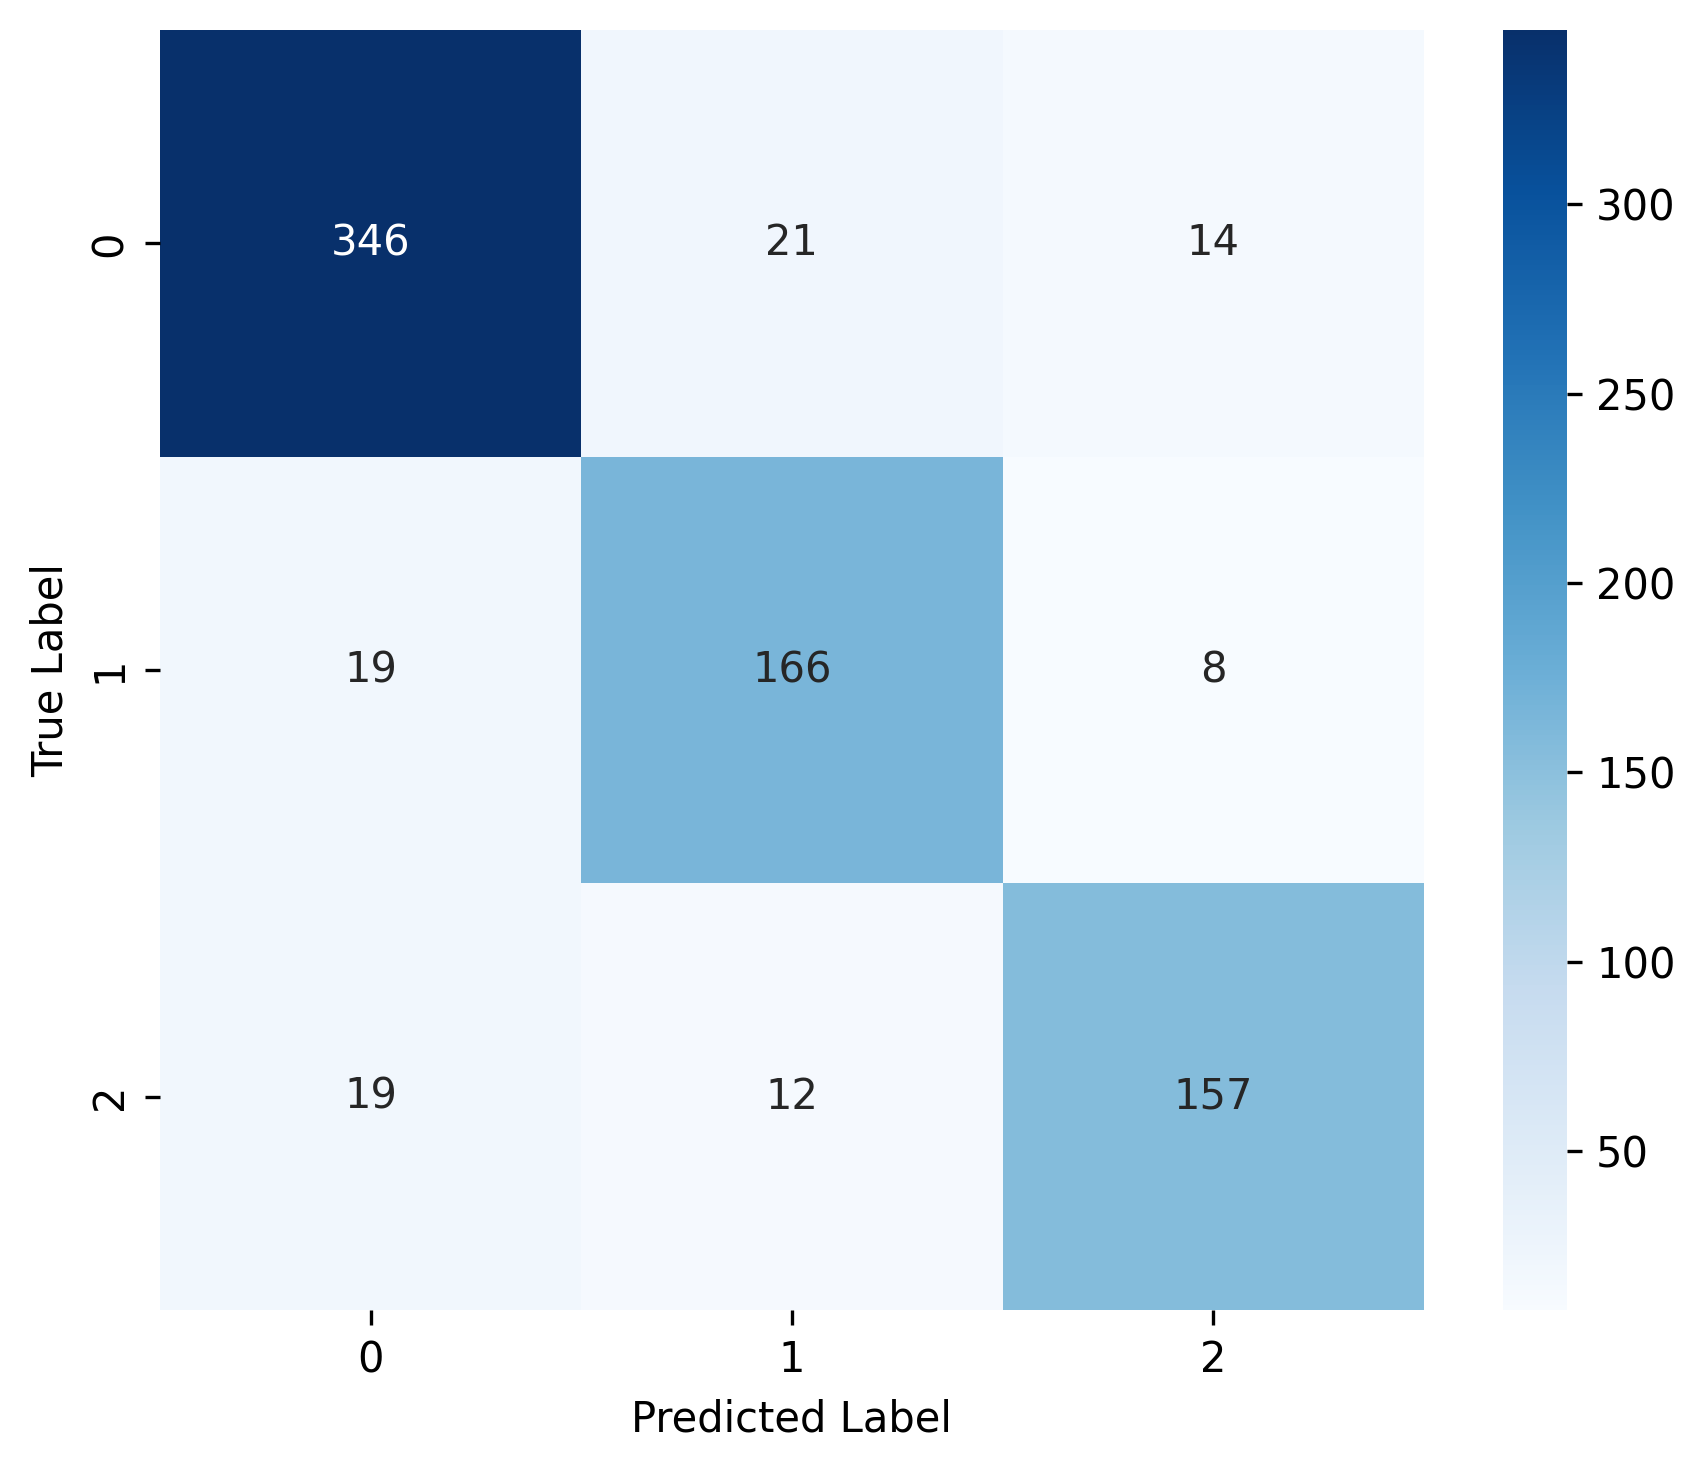

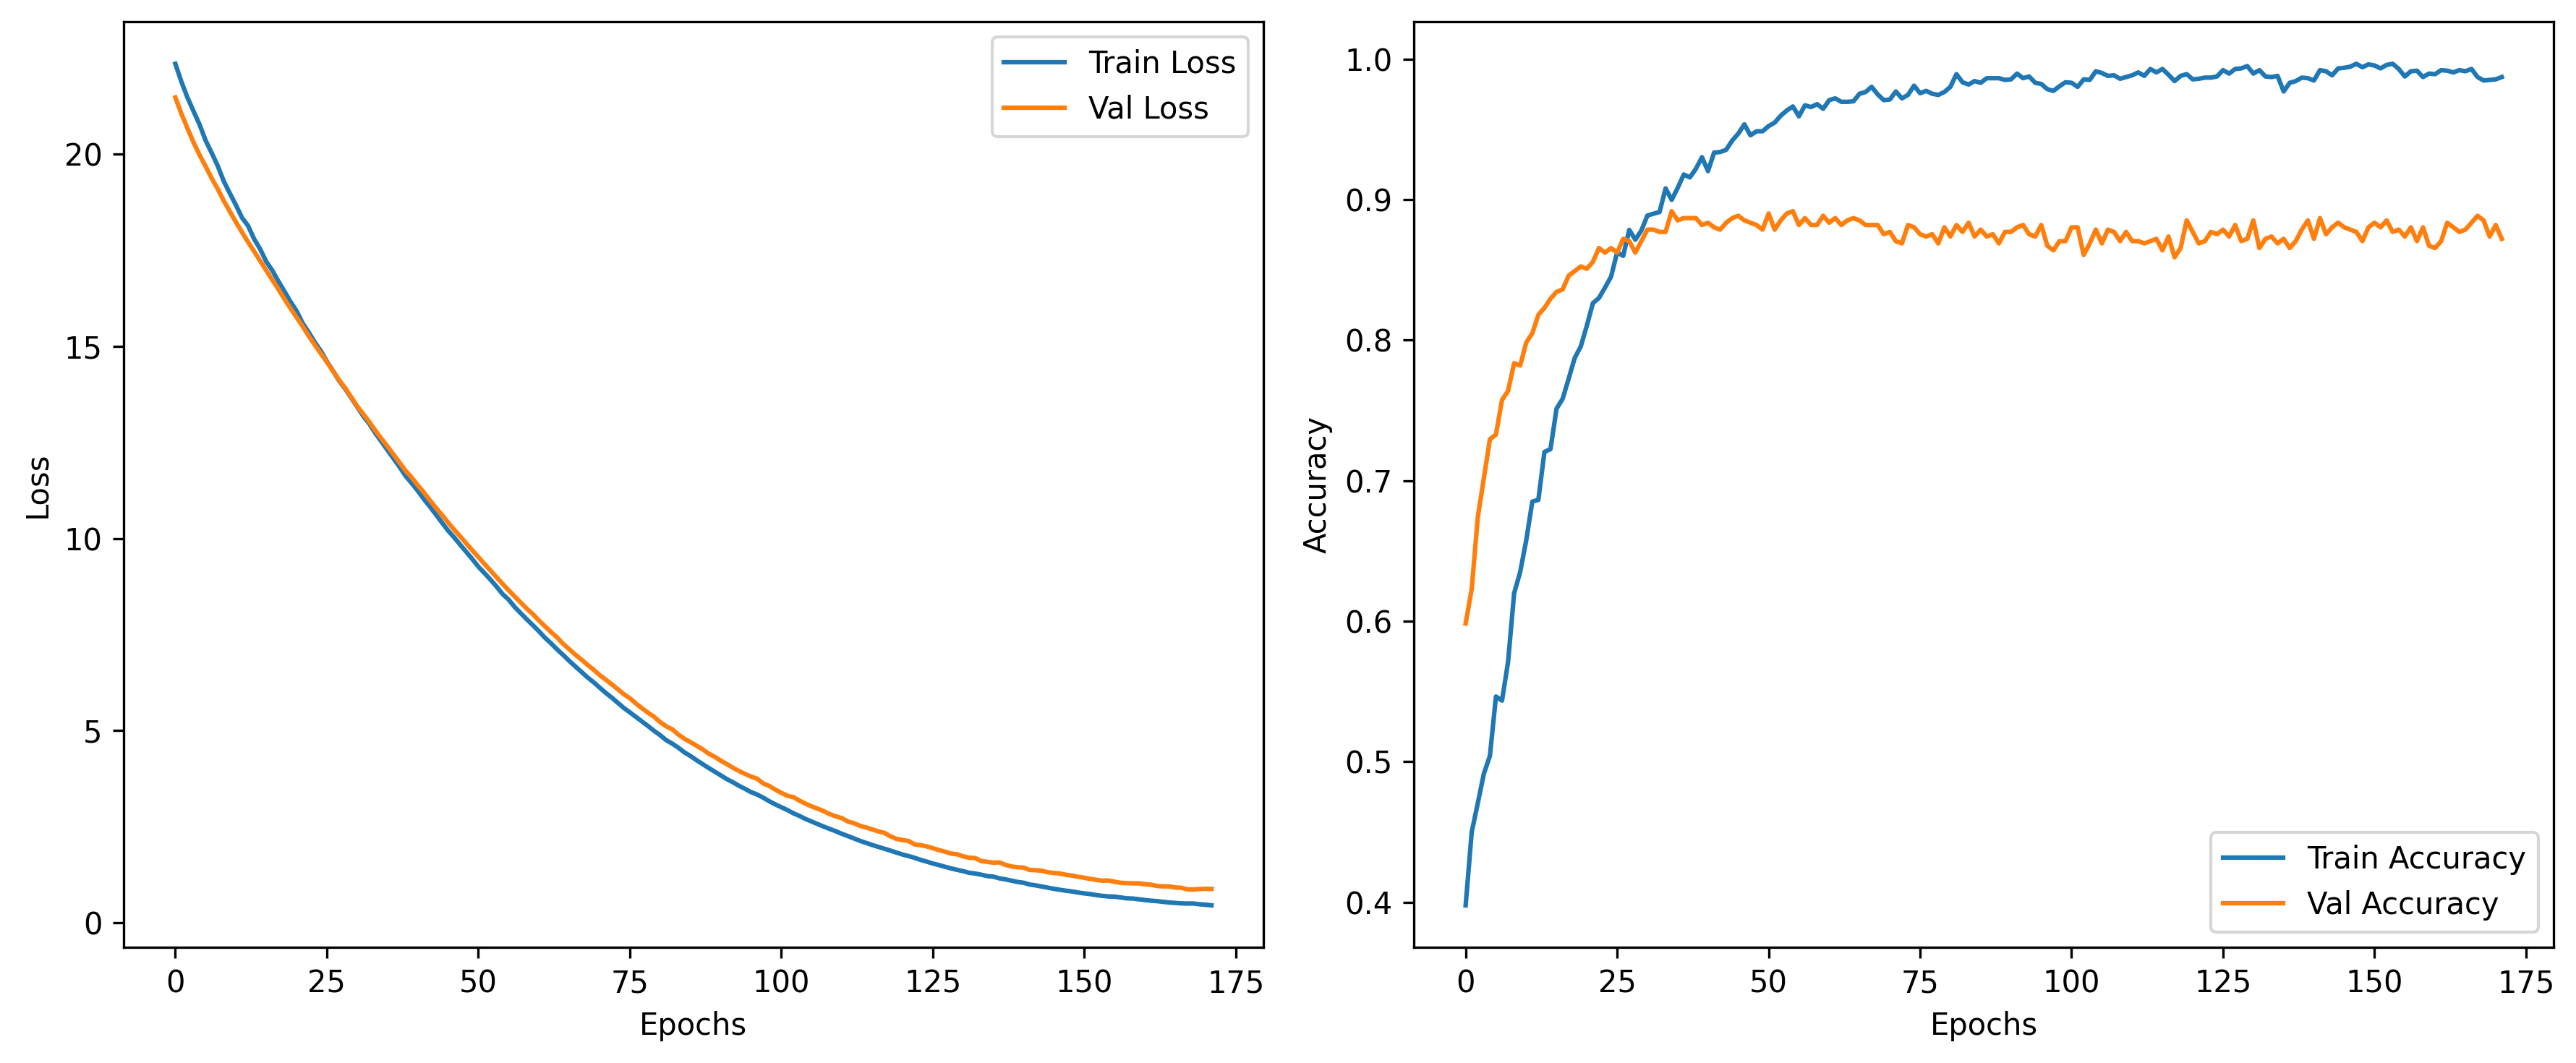

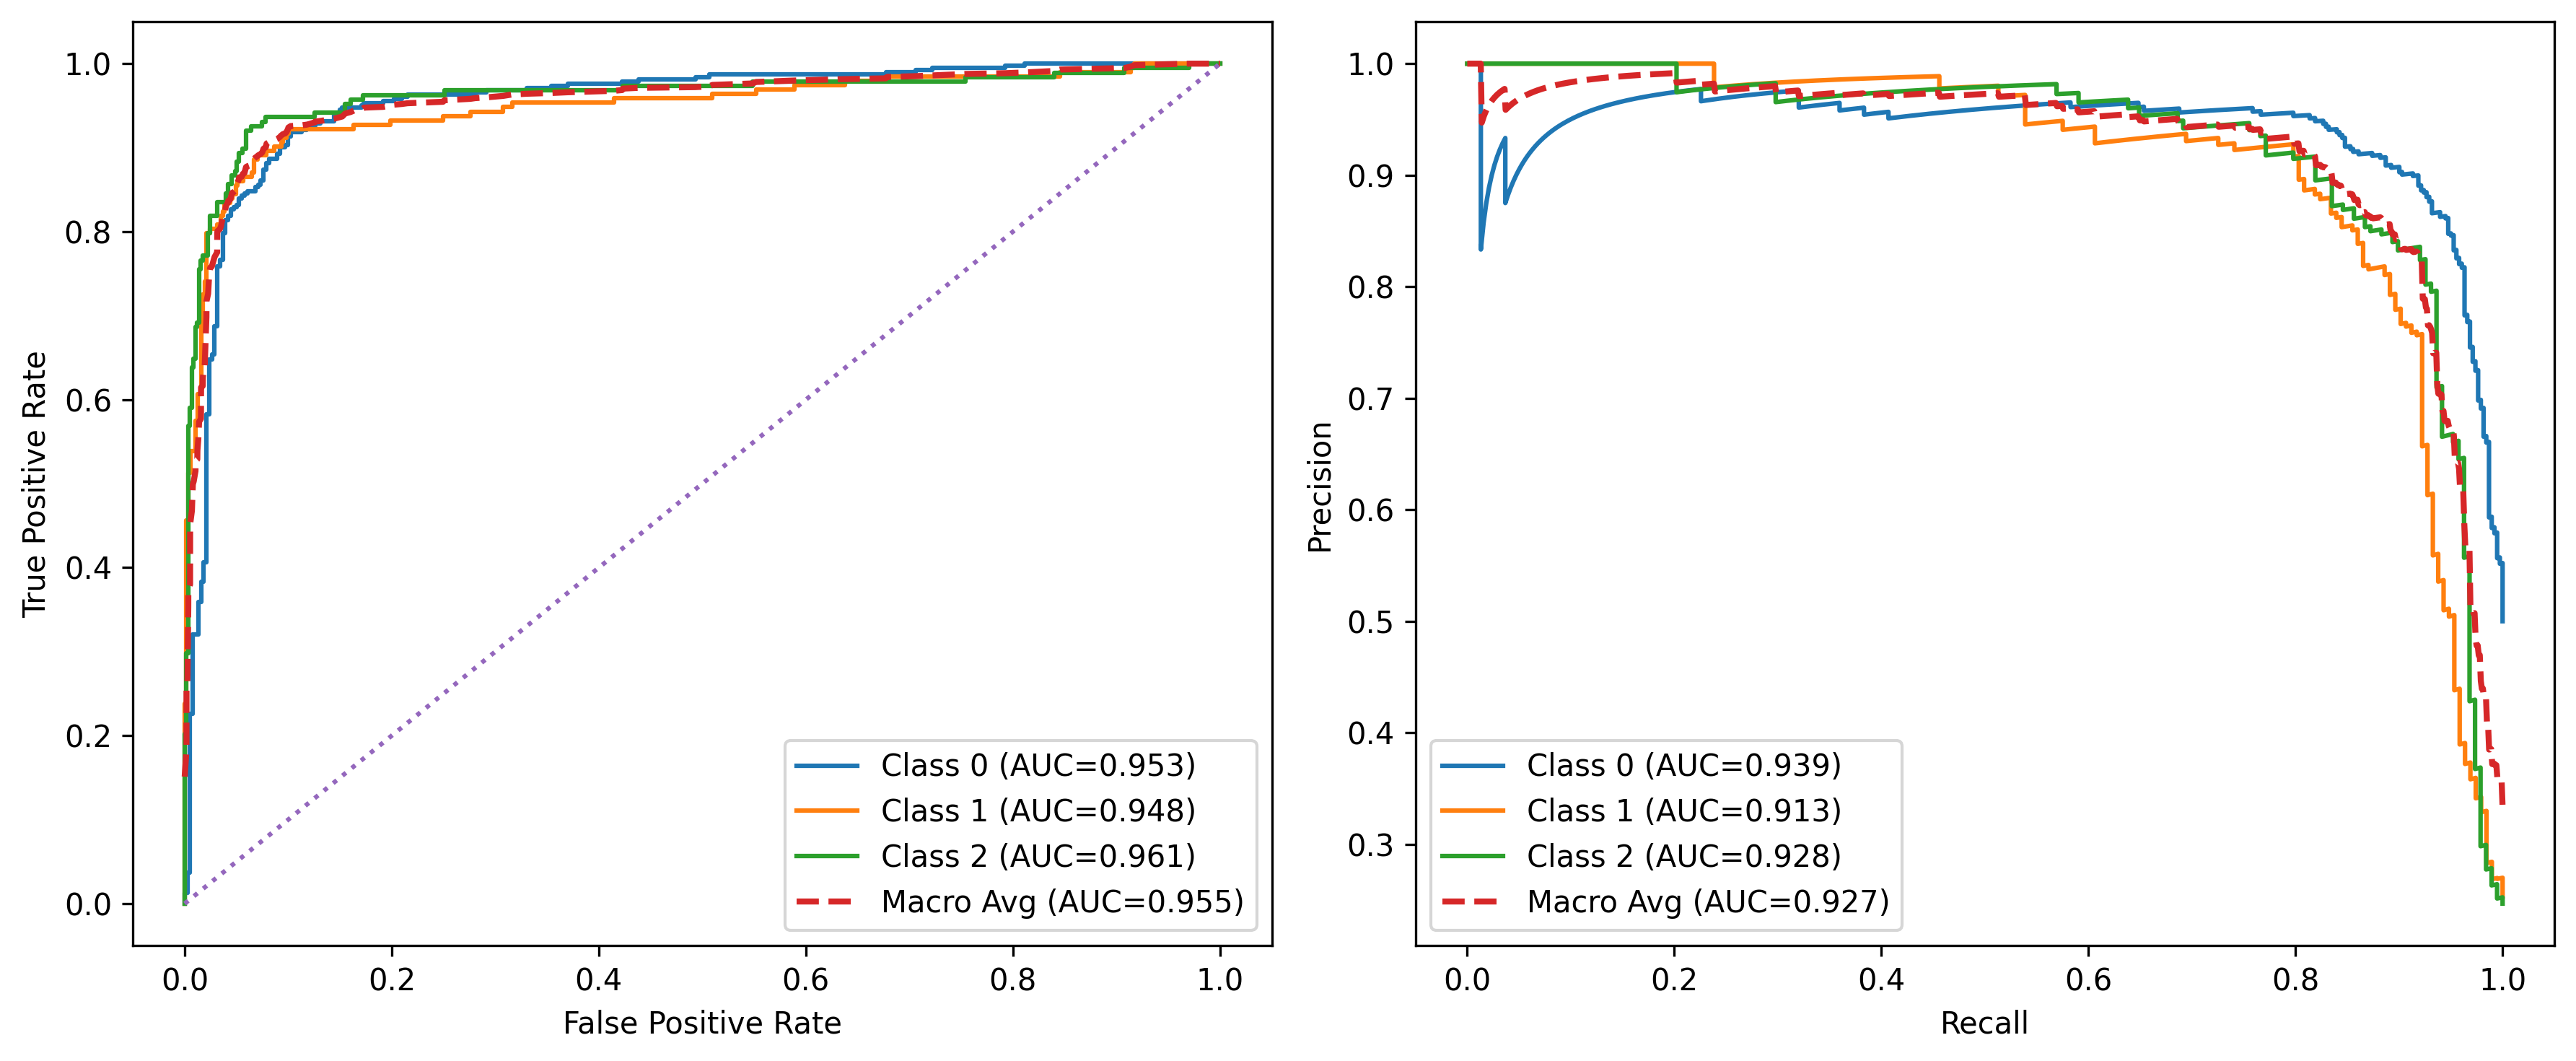

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LayerNormalization,
    GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    auc,
    f1_score,
    precision_score,
    recall_score
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

dataset_path = "/kaggle/input/datasets/proactivelearner/eeg-motor-v1/combined_eeg_features.csv"
df = pd.read_csv(dataset_path, header=None)

X = df.iloc[:, :-1].values.astype(np.float32)
y = df.iloc[:, -1].values.astype(int)

num_classes = len(np.unique(y))

print("Full data shape:", X.shape)
print("Classes        :", num_classes)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X = np.expand_dims(X, axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    shuffle=True,
    random_state=SEED
)

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Number of classes:", num_classes)

def positional_encoding(length, depth):
    pos = np.arange(length)[:, np.newaxis]
    i = np.arange(depth)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(depth))
    angle_rads = pos * angle_rates

    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    return tf.convert_to_tensor(angle_rads, dtype=tf.float32)

class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.6, l2_reg=0.05):
        super(TransformerBlock, self).__init__()

        self.att = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )

        self.ffn = tf.keras.Sequential([
            Dense(
                ff_dim,
                activation="relu",
                kernel_regularizer=tf.keras.regularizers.l2(l2_reg)
            ),
            Dense(
                embed_dim,
                kernel_regularizer=tf.keras.regularizers.l2(l2_reg)
            )
        ])

        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1, training=training)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

def build_transformer(
    input_shape,
    num_classes,
    embed_dim=32,
    num_heads=4,
    ff_dim=64,
    num_blocks=4,
    dropout_rate=0.6,
    l2_reg=0.05
):
    inputs = Input(shape=input_shape)

    positions = positional_encoding(input_shape[0], embed_dim)

    x = Dense(
        embed_dim,
        kernel_regularizer=tf.keras.regularizers.l2(l2_reg)
    )(inputs)

    x = x + positions

    for _ in range(num_blocks):
        x = TransformerBlock(
            embed_dim=embed_dim,
            num_heads=num_heads,
            ff_dim=ff_dim,
            rate=dropout_rate,
            l2_reg=l2_reg
        )(x)

    x = GlobalAveragePooling1D()(x)
    x = Dropout(dropout_rate)(x)

    outputs = Dense(
        num_classes,
        activation="softmax",
        kernel_regularizer=tf.keras.regularizers.l2(l2_reg)
    )(x)

    return Model(inputs, outputs, name="Transformer_Only")

def compute_auc_metrics(y_true, y_prob, num_classes):
    y_true_bin = to_categorical(y_true, num_classes=num_classes)

    if num_classes == 2:
        roc_auc = roc_auc_score(y_true, y_prob[:, 1])
        pr_auc = average_precision_score(y_true, y_prob[:, 1])
    else:
        roc_auc = roc_auc_score(
            y_true_bin,
            y_prob,
            multi_class="ovr",
            average="macro"
        )
        pr_auc = average_precision_score(
            y_true_bin,
            y_prob,
            average="macro"
        )

    return roc_auc, pr_auc


def compute_all_metrics(y_true, y_prob, num_classes):
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    roc_auc, pr_auc = compute_auc_metrics(y_true, y_prob, num_classes)

    return {
        "Accuracy": acc,
        "F1-Macro": f1,
        "Precision-Macro": precision,
        "Recall-Macro": recall,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Predictions": y_pred
    }

def plot_conf_matrix(y_true, y_pred, num_classes):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5), dpi=300)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=range(num_classes),
        yticklabels=range(num_classes)
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


def plot_training_history(history):
    plt.figure(figsize=(12, 5), dpi=300)

    plt.subplot(1, 2, 1)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Val Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


def plot_roc_pr_curves(y_true, y_prob, num_classes):
    y_true_bin = to_categorical(y_true, num_classes=num_classes)

    plt.figure(figsize=(12, 5), dpi=300)

    plt.subplot(1, 2, 1)

    fpr_dict = {}
    tpr_dict = {}

    for i in range(num_classes):
        fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc_i = auc(fpr_dict[i], tpr_dict[i])
        plt.plot(
            fpr_dict[i],
            tpr_dict[i],
            label=f"Class {i} (AUC={roc_auc_i:.3f})"
        )

    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(num_classes)]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(num_classes):
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])

    mean_tpr /= num_classes
    macro_roc_auc = auc(all_fpr, mean_tpr)

    plt.plot(
        all_fpr,
        mean_tpr,
        linestyle="--",
        linewidth=2,
        label=f"Macro Avg (AUC={macro_roc_auc:.3f})"
    )

    plt.plot([0, 1], [0, 1], linestyle=":")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

    plt.subplot(1, 2, 2)

    precision_dict = {}
    recall_dict = {}

    for i in range(num_classes):
        precision_dict[i], recall_dict[i], _ = precision_recall_curve(
            y_true_bin[:, i], y_prob[:, i]
        )
        pr_auc_i = auc(recall_dict[i], precision_dict[i])
        plt.plot(
            recall_dict[i],
            precision_dict[i],
            label=f"Class {i} (AUC={pr_auc_i:.3f})"
        )

    recall_grid = np.linspace(0.0, 1.0, 1000)
    mean_precision = np.zeros_like(recall_grid)

    for i in range(num_classes):
        recall_i = recall_dict[i][::-1]
        precision_i = precision_dict[i][::-1]
        interp_precision = np.interp(recall_grid, recall_i, precision_i)
        mean_precision += interp_precision

    mean_precision /= num_classes

    macro_pr_auc = average_precision_score(
        y_true_bin,
        y_prob,
        average="macro"
    )

    plt.plot(
        recall_grid,
        mean_precision,
        linestyle="--",
        linewidth=2,
        label=f"Macro Avg (AUC={macro_pr_auc:.3f})"
    )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()

    plt.tight_layout()
    plt.show()

input_shape = (X_train.shape[1], X_train.shape[2])

model = build_transformer(
    input_shape=input_shape,
    num_classes=num_classes,
    embed_dim=32,
    num_heads=4,
    ff_dim=64,
    num_blocks=4,
    dropout_rate=0.6,
    l2_reg=0.05
)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

print("\n" + "=" * 80)
print("Training Transformer_Only")
print("=" * 80)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

y_train_prob = model.predict(X_train, verbose=0)
y_test_prob = model.predict(X_test, verbose=0)

train_metrics = compute_all_metrics(y_train, y_train_prob, num_classes)
test_metrics = compute_all_metrics(y_test, y_test_prob, num_classes)

print(f"\nTransformer_Only Results")
print(f"Train Accuracy        : {train_metrics['Accuracy']:.4f}")
print(f"Test Accuracy         : {test_metrics['Accuracy']:.4f}")
print(f"Train F1-Macro        : {train_metrics['F1-Macro']:.4f}")
print(f"Test F1-Macro         : {test_metrics['F1-Macro']:.4f}")
print(f"Train Precision-Macro : {train_metrics['Precision-Macro']:.4f}")
print(f"Test Precision-Macro  : {test_metrics['Precision-Macro']:.4f}")
print(f"Train Recall-Macro    : {train_metrics['Recall-Macro']:.4f}")
print(f"Test Recall-Macro     : {test_metrics['Recall-Macro']:.4f}")
print(f"Train ROC-AUC         : {train_metrics['ROC-AUC']:.4f}")
print(f"Test ROC-AUC          : {test_metrics['ROC-AUC']:.4f}")
print(f"Train PR-AUC          : {train_metrics['PR-AUC']:.4f}")
print(f"Test PR-AUC           : {test_metrics['PR-AUC']:.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, test_metrics["Predictions"], digits=4))

print("\nPer-class One-vs-Rest ROC-AUC and PR-AUC:")

y_test_bin = to_categorical(y_test, num_classes=num_classes)

for i in range(num_classes):
    roc_auc_i = roc_auc_score(y_test_bin[:, i], y_test_prob[:, i])
    pr_auc_i = average_precision_score(y_test_bin[:, i], y_test_prob[:, i])
    print(f"Class {i}: ROC-AUC={roc_auc_i:.4f}, PR-AUC={pr_auc_i:.4f}")

plot_conf_matrix(y_test, test_metrics["Predictions"], num_classes)
plot_training_history(history)
plot_roc_pr_curves(y_test, y_test_prob, num_classes)

** **TFormerEEG model****

2026-05-10 02:57:05.233827: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778381825.443745      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778381825.503386      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778381825.945513      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778381825.945557      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778381825.945560      57 computation_placer.cc:177] computation placer alr

Total samples : 3808
Features      : 3800
Classes       : 3

  10-Fold Stratified Cross-Validation  —  Transformer Only

──────────────────────────────────────────────────────────────────────
  Fold 01 / 10
──────────────────────────────────────────────────────────────────────


I0000 00:00:1778381852.751159      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1778381857.560728     126 service.cc:152] XLA service 0x78ef34013720 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778381857.560766     126 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778381858.528966     126 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778381862.965645     126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Accuracy : 0.9108  |  F1-Macro : 0.9044  |  ROC-AUC : 0.9779  |  PR-AUC : 0.9597

──────────────────────────────────────────────────────────────────────
  Fold 02 / 10
──────────────────────────────────────────────────────────────────────
  Accuracy : 0.8845  |  F1-Macro : 0.8773  |  ROC-AUC : 0.9658  |  PR-AUC : 0.9425

──────────────────────────────────────────────────────────────────────
  Fold 03 / 10
──────────────────────────────────────────────────────────────────────
  Accuracy : 0.9239  |  F1-Macro : 0.9164  |  ROC-AUC : 0.9826  |  PR-AUC : 0.9644

──────────────────────────────────────────────────────────────────────
  Fold 04 / 10
──────────────────────────────────────────────────────────────────────
  Accuracy : 0.8871  |  F1-Macro : 0.8773  |  ROC-AUC : 0.9765  |  PR-AUC : 0.9582

──────────────────────────────────────────────────────────────────────
  Fold 05 / 10
──────────────────────────────────────────────────────────────────────
  Accuracy : 0.9003  |  F1-Macro : 0

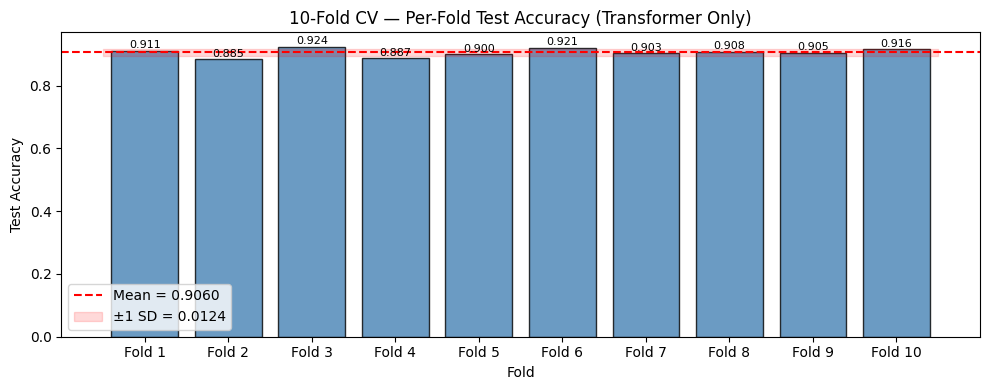

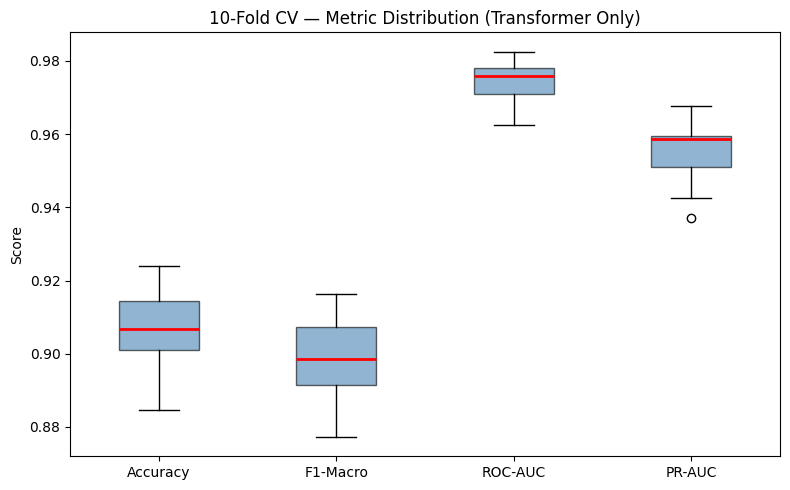

In [1]:
"""
EEG Classification - Transformer Only
Model: Linear Patch Embedding + Transformer Encoder
10-Fold Stratified Cross-Validation
"""

import os
import random
import warnings 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dropout, MultiHeadAttention, Add,
    LayerNormalization, Flatten, Dense, GaussianNoise, Reshape
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, auc,
    f1_score, precision_score, recall_score,
    classification_report
)

warnings.filterwarnings("ignore")

# ─── Seeds ────────────────────────────────────────────────────────────────────
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ─── Data ─────────────────────────────────────────────────────────────────────
DATASET_PATH = "/kaggle/input/datasets/iambiplov/eeg-wheelchair-data/combined_eeg_features.csv"
df = pd.read_csv(DATASET_PATH, header=None)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values.astype(int)
num_classes = len(np.unique(y))

print(f"Total samples : {X.shape[0]}")
print(f"Features      : {X.shape[1]}")
print(f"Classes       : {num_classes}")

# ─── Transformer building blocks ──────────────────────────────────────────────
def transformer_block(x, embed_dim):
    attn = MultiHeadAttention(num_heads=4, key_dim=embed_dim)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization()(x)
    ff = Dense(64, activation="relu", kernel_regularizer=l2(0.3))(x)
    ff = Dropout(0.6)(ff)
    ff = Dense(embed_dim, kernel_regularizer=l2(0.3))(ff)
    x = Add()([x, ff])
    x = LayerNormalization()(x)
    return x

def compile_model(model):
    model.compile(
        optimizer=Adam(learning_rate=5e-5, clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ─── Transformer Only Model ───────────────────────────────────────────────────
PATCH_SIZE = 8
EMBED_DIM  = 16

def build_transformer_only(input_shape, num_classes):
    seq_len   = input_shape[0]
    n_patches = seq_len // PATCH_SIZE

    inp = Input(shape=input_shape)
    x   = GaussianNoise(0.01)(inp)
    x   = Reshape((n_patches, PATCH_SIZE))(x)
    x   = Dense(EMBED_DIM, kernel_regularizer=l2(0.2))(x)
    x   = Dropout(0.6)(x)
    x   = transformer_block(x, EMBED_DIM)
    x   = Flatten()(x)
    out = Dense(num_classes, activation="softmax", kernel_regularizer=l2(0.2))(x)
    return compile_model(Model(inp, out, name="Transformer_Only"))

# ─── Metrics Helpers ──────────────────────────────────────────────────────────
def compute_auc_metrics(y_true, y_prob, num_classes):
    y_true_bin = to_categorical(y_true, num_classes=num_classes)
    if num_classes == 2:
        roc_auc = roc_auc_score(y_true, y_prob[:, 1])
        pr_auc  = average_precision_score(y_true, y_prob[:, 1])
    else:
        roc_auc = roc_auc_score(y_true_bin, y_prob, multi_class='ovr', average='macro')
        pr_auc  = average_precision_score(y_true_bin, y_prob, average='macro')
    return roc_auc, pr_auc

# ─── Training helper ──────────────────────────────────────────────────────────
def fit_model(model, X_tr, y_tr, epochs=500, batch=32, patience=10):
    es  = EarlyStopping(monitor="val_loss", patience=patience,
                        restore_best_weights=True, verbose=0)
    lrs = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7,
                            min_lr=1e-4, verbose=0)
    hist = model.fit(
        X_tr, y_tr,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch,
        callbacks=[es, lrs],
        verbose=0          # suppress per-epoch output; fold summary printed below
    )
    return hist

# ─── 10-Fold Stratified Cross-Validation ──────────────────────────────────────
N_SPLITS = 10
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_results = []   # list of dicts, one per fold

print("\n" + "="*70)
print(f"  10-Fold Stratified Cross-Validation  —  Transformer Only")
print("="*70)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):

    print(f"\n{'─'*70}")
    print(f"  Fold {fold:02d} / {N_SPLITS}")
    print(f"{'─'*70}")

    # ── Split ────────────────────────────────────────────────────────────────
    X_train_raw, X_test_raw = X[train_idx], X[test_idx]
    y_train_fold, y_test_fold = y[train_idx], y[test_idx]

    # ── Scale (fit only on train) ─────────────────────────────────────────────
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test  = scaler.transform(X_test_raw)

    # ── Reshape for model ─────────────────────────────────────────────────────
    X_train = np.expand_dims(X_train, axis=-1)   # (N, T, 1)
    X_test  = np.expand_dims(X_test,  axis=-1)
    input_shape = X_train.shape[1:]

    # ── Build & train ─────────────────────────────────────────────────────────
    tf.random.set_seed(SEED + fold)              # reproducible per fold
    model   = build_transformer_only(input_shape, num_classes)
    history = fit_model(model, X_train, y_train_fold)

    # ── Predictions ──────────────────────────────────────────────────────────
    y_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    # ── Metrics ──────────────────────────────────────────────────────────────
    acc     = accuracy_score(y_test_fold, y_pred)
    f1      = f1_score(y_test_fold, y_pred, average='macro', zero_division=0)
    roc_auc, pr_auc = compute_auc_metrics(y_test_fold, y_prob, num_classes)

    fold_results.append({
        "fold"    : fold,
        "accuracy": acc,
        "f1_macro": f1,
        "roc_auc" : roc_auc,
        "pr_auc"  : pr_auc,
    })

    print(f"  Accuracy : {acc:.4f}  |  F1-Macro : {f1:.4f}  "
          f"|  ROC-AUC : {roc_auc:.4f}  |  PR-AUC : {pr_auc:.4f}")

# ─── Aggregate Results ────────────────────────────────────────────────────────
results_df = pd.DataFrame(fold_results).set_index("fold")

acc_vals     = results_df["accuracy"].values
f1_vals      = results_df["f1_macro"].values
roc_auc_vals = results_df["roc_auc"].values
pr_auc_vals  = results_df["pr_auc"].values

print("\n" + "="*70)
print("  Cross-Validation Summary — Transformer Only")
print("="*70)

# Per-fold accuracy table
print("\n  Per-Fold Test Accuracies:")
print(f"  {'Fold':>5}  {'Accuracy':>10}")
print(f"  {'─'*5}  {'─'*10}")
for i, acc in enumerate(acc_vals, start=1):
    print(f"  {i:>5}  {acc:>10.4f}")

print(f"\n  Mean Accuracy : {acc_vals.mean():.4f}")
print(f"  Std  Accuracy : {acc_vals.std():.4f}")

print(f"\n  Mean F1-Macro : {f1_vals.mean():.4f}  ±  {f1_vals.std():.4f}")
print(f"  Mean ROC-AUC  : {roc_auc_vals.mean():.4f}  ±  {roc_auc_vals.std():.4f}")
print(f"  Mean PR-AUC   : {pr_auc_vals.mean():.4f}  ±  {pr_auc_vals.std():.4f}")
print("="*70)

# ─── Plot: Per-Fold Accuracy Bar Chart ───────────────────────────────────────
plt.figure(figsize=(10, 4))
bars = plt.bar(range(1, N_SPLITS + 1), acc_vals, color='steelblue', edgecolor='black', alpha=0.8)
plt.axhline(acc_vals.mean(), color='red', linestyle='--', linewidth=1.5,
            label=f"Mean = {acc_vals.mean():.4f}")
plt.fill_between(
    [0.5, N_SPLITS + 0.5],
    acc_vals.mean() - acc_vals.std(),
    acc_vals.mean() + acc_vals.std(),
    alpha=0.15, color='red', label=f"±1 SD = {acc_vals.std():.4f}"
)
for bar, val in zip(bars, acc_vals):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
             f"{val:.3f}", ha='center', va='bottom', fontsize=8)
plt.xticks(range(1, N_SPLITS + 1), [f"Fold {i}" for i in range(1, N_SPLITS + 1)])
plt.xlabel("Fold")
plt.ylabel("Test Accuracy")
plt.title("10-Fold CV — Per-Fold Test Accuracy (Transformer Only)")
plt.legend()
plt.tight_layout()
plt.show()

# ─── Plot: All Metrics Box Plot ───────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.boxplot(
    [acc_vals, f1_vals, roc_auc_vals, pr_auc_vals],
    labels=["Accuracy", "F1-Macro", "ROC-AUC", "PR-AUC"],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='red', linewidth=2)
)
plt.ylabel("Score")
plt.title("10-Fold CV — Metric Distribution (Transformer Only)")
plt.tight_layout()
plt.show()

Train shape : (3046, 3800, 1)
Test shape  : (762, 3800, 1)
Classes     : 3

 Training: Transformer Only


Model: "Transformer_Only"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 3800, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_10   │ (None, 3800, 1)   │          0 │ input_layer_10[0… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_10          │ (None, 475, 8)    │          0 │ gaussian_noise_1… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_40 (Dense)    │ (None, 475, 16)   │        144 │ reshape_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_30          │ (None, 475, 16)   │          0 │ dense_40[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 475, 16)   │      4,304 │ dropout_30[0][0], │
│ (MultiHeadAttentio… │                   │            │ dropout_30[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_20 (Add)        │ (None, 475, 16)   │          0 │ dropout_30[0][0], │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 475, 16)   │         32 │ add_20[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_41 (Dense)    │ (None, 475, 64)   │      1,088 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_32          │ (None, 475, 64)   │          0 │ dense_41[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_42 (Dense)    │ (None, 475, 16)   │      1,040 │ dropout_32[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_21 (Add)        │ (None, 475, 16)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_42[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 475, 16)   │         32 │ add_21[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_10          │ (None, 7600)      │          0 │ layer_normalizat… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_43 (Dense)    │ (None, 3)         │     22,803 │ flatten_10[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 29,443 (115.01 KB)

 Trainable params: 29,443 (115.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.3654 - loss: 19.2950 - val_accuracy: 0.6672 - val_loss: 18.1103 - learning_rate: 5.0000e-05
Epoch 2/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5564 - loss: 18.1447 - val_accuracy: 0.7557 - val_loss: 17.2635 - learning_rate: 5.0000e-05
Epoch 3/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6665 - loss: 17.2449 - val_accuracy: 0.7803 - val_loss: 16.5239 - learning_rate: 5.0000e-05
Epoch 4/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7036 - loss: 16.4896 - val_accuracy: 0.8082 - val_loss: 15.8342 - learning_rate: 5.0000e-05
Epoch 5/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7447 - loss: 15.7527 - val_accuracy: 0.8164 - val_loss: 15.1715 - learning_rate: 5.0000e-05
Epoch 6/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7835 - loss: 15.0777 - val_accuracy: 0.8246 - val_loss: 14.5248 - learning_rate: 5.0000e-05
Epoch 7/500
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

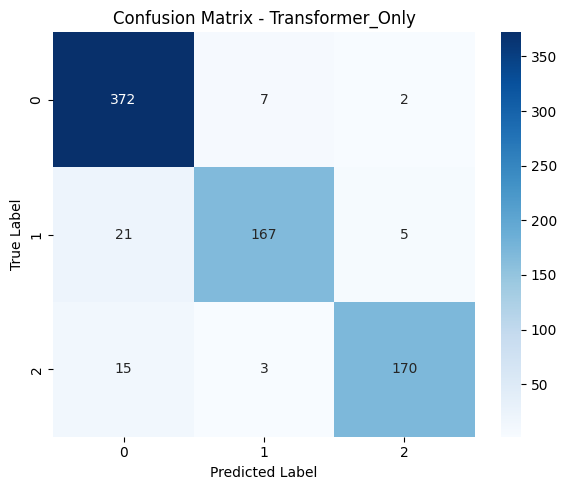

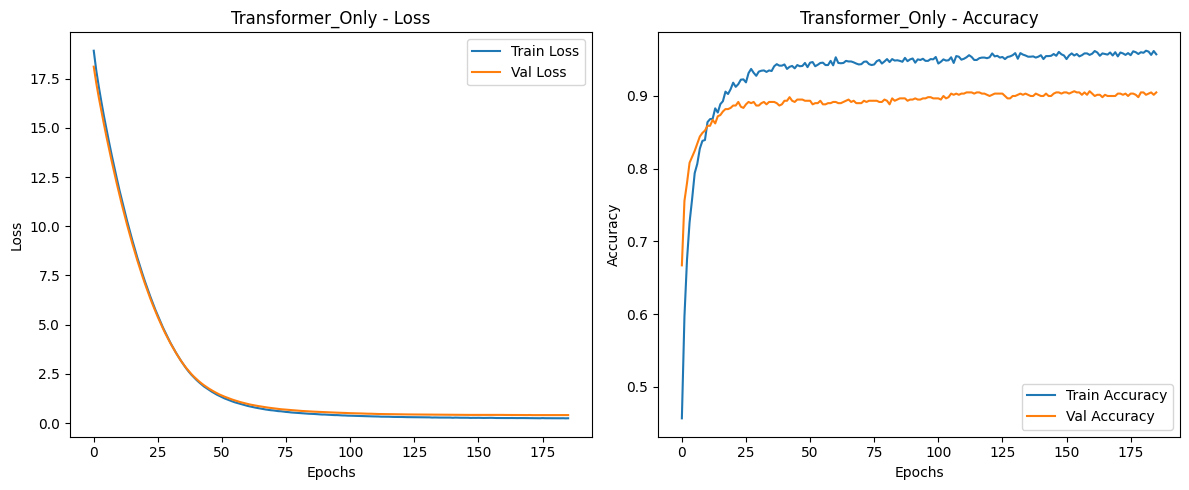

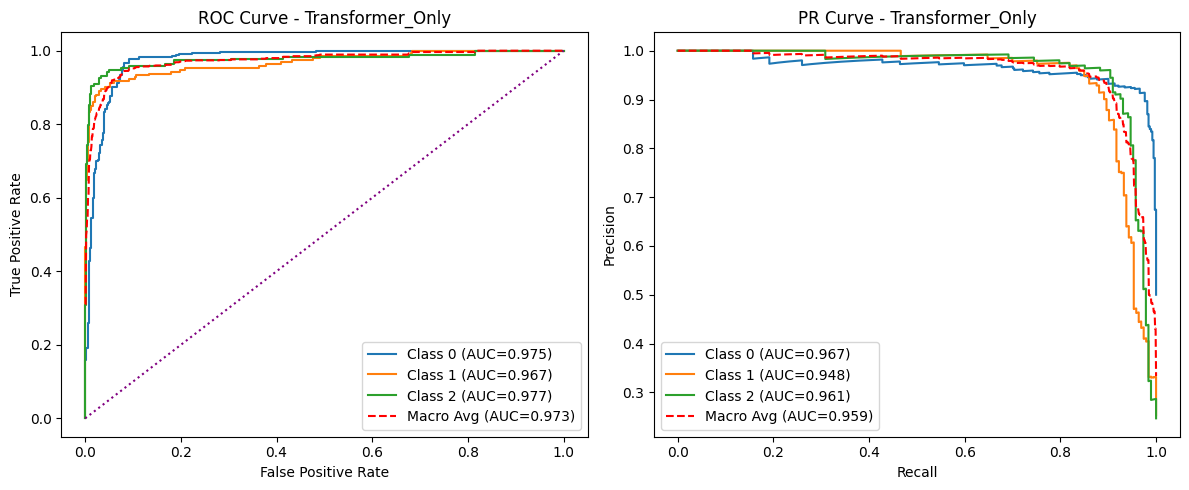

In [2]:
"""
EEG Classification - Transformer Only
Model: Linear Patch Embedding + Transformer Encoder
"""

import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dropout, MultiHeadAttention, Add,
    LayerNormalization, Flatten, Dense, GaussianNoise, Reshape
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, auc,
    f1_score, precision_score, recall_score,
    classification_report
)

warnings.filterwarnings("ignore")

# ─── Seeds ────────────────────────────────────────────────────────────────────
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ─── Data ─────────────────────────────────────────────────────────────────────
DATASET_PATH = "/kaggle/input/datasets/iambiplov/eeg-wheelchair-data/combined_eeg_features.csv"
df = pd.read_csv(DATASET_PATH, header=None)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values.astype(int)
num_classes = len(np.unique(y))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, shuffle=True, random_state=SEED
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)
input_shape = X_train.shape[1:]

print(f"Train shape : {X_train.shape}")
print(f"Test shape  : {X_test.shape}")
print(f"Classes     : {num_classes}")

# ─── Transformer building blocks ──────────────────────────────────────────────
def transformer_block(x, embed_dim):
    attn = MultiHeadAttention(num_heads=4, key_dim=embed_dim)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization()(x)
    ff = Dense(64, activation="relu", kernel_regularizer=l2(0.3))(x)
    ff = Dropout(0.6)(ff)
    ff = Dense(embed_dim, kernel_regularizer=l2(0.3))(ff)
    x = Add()([x, ff])
    x = LayerNormalization()(x)
    return x

def compile_model(model):
    model.compile(
        optimizer=Adam(learning_rate=5e-5, clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ─── Transformer Only Model ───────────────────────────────────────────────────
# Uses linear patch embedding like ViT/PatchTST. No Conv1D, no positional encoding.
PATCH_SIZE = 8  # Temporal patch length
EMBED_DIM = 16  # Embedding dimension per patch

def build_transformer_only(input_shape, num_classes):
    seq_len = input_shape[0]
    n_patches = seq_len // PATCH_SIZE

    inp = Input(shape=input_shape)  # (T, 1)
    x = GaussianNoise(0.01)(inp)

    # Linear Patch Embedding
    x = Reshape((n_patches, PATCH_SIZE))(x)           # (batch, n_patches, PATCH_SIZE)
    x = Dense(EMBED_DIM, kernel_regularizer=l2(0.2))(x)  # linear projection
    x = Dropout(0.6)(x)

    x = transformer_block(x, EMBED_DIM)
    x = Flatten()(x)
    out = Dense(num_classes, activation="softmax", kernel_regularizer=l2(0.2))(x)
    return compile_model(Model(inp, out, name="Transformer_Only"))

# =========================
# Metrics Helpers
# =========================
def compute_auc_metrics(y_true, y_prob, num_classes):
    """
    Returns macro AUC-ROC and macro AUC-PRC.
    Works for binary and multiclass.
    """
    y_true_bin = to_categorical(y_true, num_classes=num_classes)

    if num_classes == 2:
        # Use positive-class probability
        roc_auc = roc_auc_score(y_true, y_prob[:, 1])
        pr_auc = average_precision_score(y_true, y_prob[:, 1])
    else:
        roc_auc = roc_auc_score(
            y_true_bin, y_prob,
            multi_class='ovr',
            average='macro'
        )
        pr_auc = average_precision_score(
            y_true_bin, y_prob,
            average='macro'
        )

    return roc_auc, pr_auc


def plot_conf_matrix(y_true, y_pred, model_name, num_classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=range(num_classes),
        yticklabels=range(num_classes)
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()


def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{model_name} - Loss')
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()


def plot_roc_pr_curves(y_true, y_prob, num_classes, model_name):
    y_true_bin = to_categorical(y_true, num_classes=num_classes)

    plt.figure(figsize=(12, 5))

    # ---------------------
    # ROC Curve
    # ---------------------
    plt.subplot(1, 2, 1)

    if num_classes == 2:
        fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    else:
        all_fpr = np.linspace(0, 1, 1000)
        tpr_sum = np.zeros_like(all_fpr)

        for i in range(num_classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
            roc_auc_i = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc_i:.3f})")
            tpr_sum += np.interp(all_fpr, fpr, tpr)

        macro_tpr = tpr_sum / num_classes
        macro_auc = auc(all_fpr, macro_tpr)
        plt.plot(all_fpr, macro_tpr, linestyle='--', color='red',
                 label=f"Macro Avg (AUC={macro_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle=':', color='purple')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend(loc='lower right')

    # ---------------------
    # PR Curve
    # ---------------------
    plt.subplot(1, 2, 2)

    if num_classes == 2:
        precision, recall, _ = precision_recall_curve(y_true, y_prob[:, 1])
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, label=f"AUC = {pr_auc:.4f}")
    else:
        all_recall = np.linspace(0, 1, 1000)
        prec_sum = np.zeros_like(all_recall)

        for i in range(num_classes):
            precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
            pr_auc_i = auc(recall, precision)
            plt.plot(recall, precision, label=f"Class {i} (AUC={pr_auc_i:.3f})")
            prec_sum += np.interp(all_recall, recall[::-1], precision[::-1])

        macro_prec = prec_sum / num_classes
        macro_pr_auc = auc(all_recall, macro_prec)
        plt.plot(all_recall, macro_prec, linestyle='--', color='red',
                 label=f"Macro Avg (AUC={macro_pr_auc:.3f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve - {model_name}")
    plt.legend(loc='lower left')

    plt.tight_layout()
    plt.show()

# ─── Training ─────────────────────────────────────────────────────────────────
def fit_model(model, X_tr, y_tr, epochs=500, batch=32, patience=10):
    es = EarlyStopping(monitor="val_loss", patience=patience,
                       restore_best_weights=True, verbose=1)
    lrs = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7,
                            min_lr=1e-4, verbose=1)
    hist = model.fit(X_tr, y_tr,
                     validation_split=0.2, epochs=epochs, batch_size=batch,
                     callbacks=[es, lrs], verbose=1)
    return hist

# ─── Main ─────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print(" Training: Transformer Only")
print("="*70)

model_name = "Transformer_Only"
model = build_transformer_only(input_shape, num_classes)
model.summary()

history = fit_model(model, X_train, y_train)

# Predictions
y_train_prob = model.predict(X_train, verbose=0)
y_test_prob = model.predict(X_test, verbose=0)

y_train_pred = np.argmax(y_train_prob, axis=1)
y_test_pred = np.argmax(y_test_prob, axis=1)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

# AUC metrics
train_roc_auc, train_pr_auc = compute_auc_metrics(y_train, y_train_prob, num_classes)
test_roc_auc, test_pr_auc = compute_auc_metrics(y_test, y_test_prob, num_classes)

print(f"\n{model_name} Results")
print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Train ROC-AUC  : {train_roc_auc:.4f}")
print(f"Test ROC-AUC   : {test_roc_auc:.4f}")
print(f"Train PR-AUC   : {train_pr_auc:.4f}")
print(f"Test PR-AUC    : {test_pr_auc:.4f}")

print("\n Classification Report (Test):")
print(classification_report(y_test, y_test_pred))

# Plots
plot_conf_matrix(y_test, y_test_pred, model_name, num_classes)
plot_training_history(history, model_name)
plot_roc_pr_curves(y_test, y_test_prob, num_classes, model_name)